# True Truncation NEQS8 Only

Let's confirm information for NEQs=8 only run. Specifically $\Delta$$N$ business.

In [1]:
import numpy as np
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors as mcolors
from matplotlib.ticker import ScalarFormatter


import sys
import os
import glob


#Should modify the Python import path at runtime
sys.path.append('/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels')


from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import re

from scipy.interpolate import UnivariateSpline, splrep, splev, CubicSpline, interp1d, PchipInterpolator, InterpolatedUnivariateSpline
import numdifftools as nd
from scipy.integrate import cumulative_trapezoid, solve_ivp, odeint


from pathlib import Path



Reuseables:

In [2]:
SCAN_INFO = {
    5: ("lam2",  r"\lambda_2"),
    6: ("lam3",  r"\lambda_3"),
    7: ("lam4",  r"\lambda_4"),
    8: ("lam5",  r"\lambda_5"),
    9: ("lam6",  r"\lambda_6"),
    10: ("lam7", r"\lambda_7"),
    11: ("lam8", r"\lambda_8"),
    12: ("lam9", r"\lambda_9"),
    13: ("lam10", r"\lambda_{10}"),
}

colors = {
    5: "pink",
    6: "turquoise",
    7: "plum",
    8: "mediumslateblue",
    9: "blue",
}

def load_path_data(NEQS, param_name, value):
    val_str = f"{value:.10e}"
    folder = os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}",
    )
    file_path = os.path.join(
        folder,
        f"path_neqs{NEQS}_{param_name}_{val_str}.dat",
    )
    return pd.read_csv(file_path, sep=r"\s+", header=None).values

def folder_for(NEQS, param_name, value):
    val_str = f"{value:.10e}"
    return os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}"
    )

def load_specs(NEQS, param_name, value):
    folder = folder_for(NEQS, param_name, value)

    s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
    t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

    k_s = s[:, 0]
    Ps = np.abs(s[:, 1])

    k_t = t[:, 0]
    Pt = np.abs(t[:, 1])

    return k_s, Ps, k_t, Pt


    
def prepare_increasing(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    order = np.argsort(x)
    return x[order], y[order]

def normalize_curve_at_Nref(N, Y, N_ref=60.0, ref_floor=1e-20):
    N_use, Y_use = prepare_increasing(N, Y)

    if not (N_use.min() <= N_ref <= N_use.max()):
        raise ValueError(
            f"N_ref={N_ref} outside range [{N_use.min()}, {N_use.max()}]"
        )

    Y_ref = np.interp(N_ref, N_use, Y_use)

    if np.abs(Y_ref) < ref_floor:
        raise ValueError(f"Reference too small: {Y_ref:.3e}")

    return N_use, Y_use / Y_ref, Y_ref

def normalize_at_ref(k, P):
        k, P = prepare_increasing(k, P)
        P_ref = np.interp(k_ref, k, P)
        return k, P / P_ref, P_ref


def fractional_difference_on_overlap(x, y, x_ref, y_ref, frac_floor=1e-30):
    x, y = prepare_increasing(x, y)
    x_ref, y_ref = prepare_increasing(x_ref, y_ref)

    xmin = max(np.min(x), np.min(x_ref))
    xmax = min(np.max(x), np.max(x_ref))

    mask = (x >= xmin) & (x <= xmax)

    x_use = x[mask]
    y_use = y[mask]

    y_ref_interp = np.interp(x_use, x_ref, y_ref)

    frac = (y_use - y_ref_interp) / np.where(
        np.abs(y_ref_interp) > frac_floor,
        y_ref_interp,
        np.nan,
    )

    return x_use, frac


def get_base_dir(NEQS, param_name, base_value, base_path_root):
    val_str = f"{base_value:.10e}"
    folder = os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}"
    )

    if not os.path.exists(folder):
        raise FileNotFoundError(f"Missing base folder: {folder}")

    return folder



def get_param_values_from_dirs(NEQS, param_name, base_path_root, show_summary=True):
    base_path = f"{base_path_root}/neqs{NEQS}"
    pattern = os.path.join(base_path, f"{param_name}_*")
    dirs = glob.glob(pattern)

    values = []

    for d in dirs:
        try:
            base = os.path.basename(d)
            val_str = base.replace(f"{param_name}_", "")
            val = float(val_str)
            label = rf"${param_name} = {val:.1e}$"
            values.append((val, label))
        except Exception as e:
            print(f"Skipping {d}: {e}")

    values.sort(key=lambda x: x[0])

    if show_summary:
        print(f"\n{'='*60}")
        print(f"Summary for NEQS={NEQS}, parameter={param_name}")
        print(f"{'='*60}")
        print(f"Total models found: {len(values)}")
        if len(values) > 0:
            print(f"Parameter range: {values[0][0]:.3e} to {values[-1][0]:.3e}")
        else:
            print("Parameter range: none found")
        print(f"{'='*60}\n")

    return values

Calling bases:

In [3]:
LAM_BASE = {
    7: ("lam4",  6.87065e-8),
    8: ("lam5", -8.92461e-9),
    9: ("lam6", 6.1e-10), #we can test 9 later if we really want to 
}


base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"


base_dirs = {}

for NEQS, (param_name, base_val) in LAM_BASE.items():
    folder = get_base_dir(NEQS, param_name, base_val, base_path_root)
    base_dirs[NEQS] = {
        "param_name": param_name,
        "value": base_val,
        "folder": folder
    }

    print(f"NEQS={NEQS}: {folder}")

NEQS=7: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs7/lam4_6.8706500000e-08
NEQS=8: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs8/lam5_-8.9246100000e-09
NEQS=9: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs9/lam6_6.1000000000e-10


In [4]:
lam6_values = get_param_values_from_dirs(9, "lam6", base_path_root)
lam5_values = get_param_values_from_dirs(8, "lam5", base_path_root)
lam4_values = get_param_values_from_dirs(7, "lam4", base_path_root)



Summary for NEQS=9, parameter=lam6
Total models found: 6
Parameter range: 6.100e-10 to 3.400e-06


Summary for NEQS=8, parameter=lam5
Total models found: 75
Parameter range: -4.979e-05 to 4.798e-05


Summary for NEQS=7, parameter=lam4
Total models found: 30
Parameter range: -1.457e-04 to 4.872e-04



# BEFORE APPLYING SHIFT:

Plot spectra variation

In [70]:
def plot_filtered_spectra_by_ns(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    ns_min=0.955,
    ns_max=0.971,
    ns_target=0.967,
    k_ref=0.05,
    k_min_scalar=None,
    k_max_scalar=10.0,
    cmap_name="plasma",
    save_name=None,
    show=True,
):
    
    
    plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif"],

    "axes.labelsize": 22,
    "axes.titlesize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15,
    "figure.titlesize": 24,

    "axes.linewidth": 1.3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    })

        
        
    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array(
            [x[0] if isinstance(x, tuple) else x for x in vals],
            dtype=float,
        )

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{scan_name}_{val_str}",
        )

    def load_observables(value):
        arr = np.loadtxt(
            os.path.join(folder_for(value), f"test_nr_neqs{NEQS}.dat")
        )
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]

    def load_specs(value):
        folder = folder_for(value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s = s[:, 0]
        Ps = np.abs(s[:, 1])

        k_t = t[:, 0]
        Pt = np.abs(t[:, 1])

        return k_s, Ps, k_t, Pt

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)

        dx = np.diff(x)

        if np.all(dx >= 0):
            return x, y
        elif np.all(dx <= 0):
            return x[::-1], y[::-1]
        else:
            order = np.argsort(x)
            return x[order], y[order]

    def normalize_at_ref(x, y, x_ref):
        x, y = prepare_increasing(x, y)

        if not (np.min(x) <= x_ref <= np.max(x)):
            raise ValueError(
                f"k_ref={x_ref} outside range [{np.min(x):.4e}, {np.max(x):.4e}]"
            )

        y_ref = np.interp(x_ref, x, y)

        if np.abs(y_ref) < 1e-30:
            raise ValueError(f"Reference value too small at k_ref={x_ref}")

        return x, y / y_ref

    def scalar_k_mask(k):
        mask = np.ones_like(k, dtype=bool)

        if k_min_scalar is not None:
            mask &= k >= k_min_scalar

        if k_max_scalar is not None:
            mask &= k <= k_max_scalar

        return mask

    def frac_on_base_grid(
        x_base,
        y_base,
        x_cmp,
        y_cmp,
        xmin=None,
        xmax=None,
    ):
        x_base, y_base = prepare_increasing(x_base, y_base)
        x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

        xlo = max(np.min(x_base), np.min(x_cmp))
        xhi = min(np.max(x_base), np.max(x_cmp))

        if xmin is not None:
            xlo = max(xlo, xmin)

        if xmax is not None:
            xhi = min(xhi, xmax)

        mask = (x_base >= xlo) & (x_base <= xhi)

        x_use = x_base[mask]
        y_base_use = y_base[mask]

        if len(x_use) == 0:
            raise ValueError(
                f"No overlapping k-values in requested range [{xlo:.4e}, {xhi:.4e}]"
            )

        y_cmp_interp = np.interp(x_use, x_cmp, y_cmp)

        frac = (y_cmp_interp - y_base_use) / y_base_use

        return x_use, frac

    lam_vals = sanitize_lam_values(lamX_values)

    r_base, ns_base, alpha_base = load_observables(baseX)

    k_s_base_raw, Ps_base_raw, k_t_base_raw, Pt_base_raw = load_specs(baseX)

    k_s_base, Ps_base_norm = normalize_at_ref(k_s_base_raw, Ps_base_raw, k_ref)
    k_t_base, Pt_base_norm = normalize_at_ref(k_t_base_raw, Pt_base_raw, k_ref)

    rows = []
    kept_models = []

    for lamX in lam_vals:
        try:
            r, ns, alpha_s = load_observables(lamX)

            k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(lamX)

            k_s, Ps_norm = normalize_at_ref(k_s_raw, Ps_raw, k_ref)
            k_t, Pt_norm = normalize_at_ref(k_t_raw, Pt_raw, k_ref)

            k_ps_err, frac_ps = frac_on_base_grid(
                k_s_base,
                Ps_base_norm,
                k_s,
                Ps_norm,
                xmin=k_min_scalar,
                xmax=k_max_scalar,
            )

            k_pt_err, frac_pt = frac_on_base_grid(
                k_t_base,
                Pt_base_norm,
                k_t,
                Pt_norm,
                xmin=None,
                xmax=None,
            )

            mean_dPs_pct = 100.0 * np.nanmean(frac_ps)
            max_dPs_pct = 100.0 * np.nanmax(np.abs(frac_ps))
            mean_dPt_pct = 100.0 * np.nanmean(frac_pt)
            max_dPt_pct = 100.0 * np.nanmax(np.abs(frac_pt))

            keep = ns_min <= ns <= ns_max

            row = {
                "lamX": lamX,
                "r": r,
                "ns": ns,
                "alpha_s": alpha_s,
                "delta_ns_from_base": ns - ns_base,
                "delta_ns_from_target": ns - ns_target,
                "mean_dPs_pct": mean_dPs_pct,
                "max_dPs_pct": max_dPs_pct,
                "mean_dPt_pct": mean_dPt_pct,
                "max_dPt_pct": max_dPt_pct,
                "kept_by_ns_cut": keep,
            }

            rows.append(row)

            if keep:
                kept_models.append({
                    **row,
                    "k_s": k_s,
                    "Ps_norm": Ps_norm,
                    "k_t": k_t,
                    "Pt_norm": Pt_norm,
                    "k_ps_err": k_ps_err,
                    "frac_ps": frac_ps,
                    "k_pt_err": k_pt_err,
                    "frac_pt": frac_pt,
                })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name}={lamX:.5e}: {e}")

    stats_df = pd.DataFrame(rows).sort_values("ns")
    kept_df = stats_df[stats_df["kept_by_ns_cut"]].copy()

    print("\n=== All models summary ===")
    print(f"Total loaded: {len(stats_df)}")
    print(f"Base ns: {ns_base:.6f}")
    print(f"Models in ns window [{ns_min}, {ns_max}]: {len(kept_df)}")

    if not kept_df.empty:
        print("\n=== Filtered models by ns cut ===")
        print(
            kept_df[[
                "lamX",
                "ns",
                "delta_ns_from_base",
                "mean_dPs_pct",
                "max_dPs_pct",
                "mean_dPt_pct",
                "max_dPt_pct",
            ]].to_string(index=False)
        )

        print("\n=== Error shrink check in percentages ===")
        print("All models:")
        print(
            stats_df[[
                "mean_dPs_pct",
                "max_dPs_pct",
                "mean_dPt_pct",
                "max_dPt_pct",
            ]]
            .agg(["mean", "max"])
            .to_string()
        )

        print("\nFiltered models:")
        print(
            kept_df[[
                "mean_dPs_pct",
                "max_dPs_pct",
                "mean_dPt_pct",
                "max_dPt_pct",
            ]]
            .agg(["mean", "max"])
            .to_string()
        )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(18, 12),
        constrained_layout=True,
    )

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    if len(kept_models) > 0:
        lam_kept = np.array([m["lamX"] for m in kept_models])
        cmap = plt.get_cmap(cmap_name)
        norm = mcolors.Normalize(vmin=np.min(lam_kept), vmax=np.max(lam_kept))

        for m in kept_models:
            color = cmap(norm(m["lamX"]))

            mask_ps_plot = scalar_k_mask(m["k_s"])

            ax_ps.loglog(
                m["k_s"][mask_ps_plot],
                m["Ps_norm"][mask_ps_plot],
                color=color,
                lw=1.8,
                alpha=0.85,
            )

            ax_pt.loglog(
                m["k_t"],
                m["Pt_norm"],
                color=color,
                lw=1.8,
                alpha=0.85,
            )

            ax_ps_err.semilogx(
                m["k_ps_err"],
                100.0 * m["frac_ps"],
                color=color,
                lw=1.5,
                alpha=0.85,
            )

            ax_pt_err.semilogx(
                m["k_pt_err"],
                100.0 * m["frac_pt"],
                color=color,
                lw=1.5,
                alpha=0.85,
            )

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        fig.colorbar(sm, ax=axes, label=rf"${scan_symbol}$")

    mask_base_s = scalar_k_mask(k_s_base)

    ax_ps.loglog(
        k_s_base[mask_base_s],
        Ps_base_norm[mask_base_s],
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_pt.loglog(
        k_t_base,
        Pt_base_norm,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    for ax in [ax_ps_err, ax_pt_err]:
        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=0.8,
            alpha=0.6,
        )

    ax_ps.axvline(k_ref, color="black", ls=":", alpha=0.7)
    ax_pt.axvline(k_ref, color="black", ls=":", alpha=0.7)
    
    # Approximate N=60 scale (CMB pivot)
    k_N60 = 0.05

    # Approximate N=20 scale
    k_N20 = 1e15

    ax_Pt.axvline(
        k_N60,
        color="darkgreen",
        ls="--",
        lw=2.0,
        alpha=0.9,
    )

    ax_Pt.axvline(
        k_N20,
        color="firebrick",
        ls="--",
        lw=2.0,
        alpha=0.9,
    )

    ax_Pt.text(
        k_N60,
        ax_Pt.get_ylim()[1] * 0.8,
        r"$N\!\sim\!60$",
        rotation=90,
        color="darkgreen",
        ha="right",
        va="top",
    )

    ax_Pt.text(
        k_N20,
        ax_Pt.get_ylim()[1] * 0.8,
        r"$N\!\sim\!20$",
        rotation=90,
        color="firebrick",
        ha="right",
        va="top",
    )

    ax_ps.set_title(
        rf"Filtered normalized scalar spectra: $P_s/P_s({k_ref})$"
    )
    ax_pt.set_title(
        rf"Filtered normalized tensor spectra: $P_t/P_t({k_ref})$"
    )
    ax_ps_err.set_title(r"Filtered scalar fractional error")
    ax_pt_err.set_title(r"Filtered tensor fractional error")

    ax_ps.set_xlabel(r"$k$")
    ax_pt.set_xlabel(r"$k$")
    ax_ps_err.set_xlabel(r"$k$")
    ax_pt_err.set_xlabel(r"$k$")

    ax_ps.set_ylabel(r"$P_s/P_s(k_{\rm ref})$")
    ax_pt.set_ylabel(r"$P_t/P_t(k_{\rm ref})$")
    ax_ps_err.set_ylabel(r"$100\times\Delta P_s/P_{s,\rm base}$")
    ax_pt_err.set_ylabel(r"$100\times\Delta P_t/P_{t,\rm base}$")

    xmin_scalar = (
        k_min_scalar
        if k_min_scalar is not None
        else np.min(k_s_base[mask_base_s])
    )

    xmax_scalar = (
        k_max_scalar
        if k_max_scalar is not None
        else np.max(k_s_base[mask_base_s])
    )

    ax_ps.set_xlim(xmin_scalar, xmax_scalar)
    ax_ps_err.set_xlim(xmin_scalar, xmax_scalar)

    for ax in axes.ravel():
        ax.grid(True, alpha=0.25)
        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(fontsize=15)

    fig.suptitle(
        rf"Models with ${ns_min} \leq n_s \leq {ns_max}$ "
        rf"(target $n_s={ns_target}$)",
        fontsize=24,
    )

    if save_name is None:
        save_name = (
            f"neqs{NEQS}_{scan_name}_filtered_ns_"
            f"{ns_min}_{ns_max}_kmin{k_min_scalar}_kmax{k_max_scalar}.png"
        )

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return stats_df, kept_df


=== All models summary ===
Total loaded: 75
Base ns: 0.969485
Models in ns window [0.963, 0.971]: 75

=== Filtered models by ns cut ===
         lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
 2.023740e-05 0.963575           -0.005910      4.325933     8.345970      1.861479     8.959331
-4.368160e-05 0.963749           -0.005737     -7.786386    12.134618      1.827040     9.418645
-1.702759e-05 0.963908           -0.005578      0.724281     2.054979      1.257745     8.316724
-4.876636e-06 0.963949           -0.005536    -25.895699    45.031048      1.172852     7.309817
 1.553792e-06 0.963949           -0.005536      4.032116     7.680990      1.836719     8.889135
 1.005003e-06 0.964059           -0.005426     -6.160717     9.601796      1.780187     9.322246
-3.455518e-05 0.964106           -0.005380     -5.835665     9.207740      1.795709     9.363065
 1.416172e-05 0.964303           -0.005182      1.571153     3.842246      1.985739    

NameError: name 'ax_Pt' is not defined

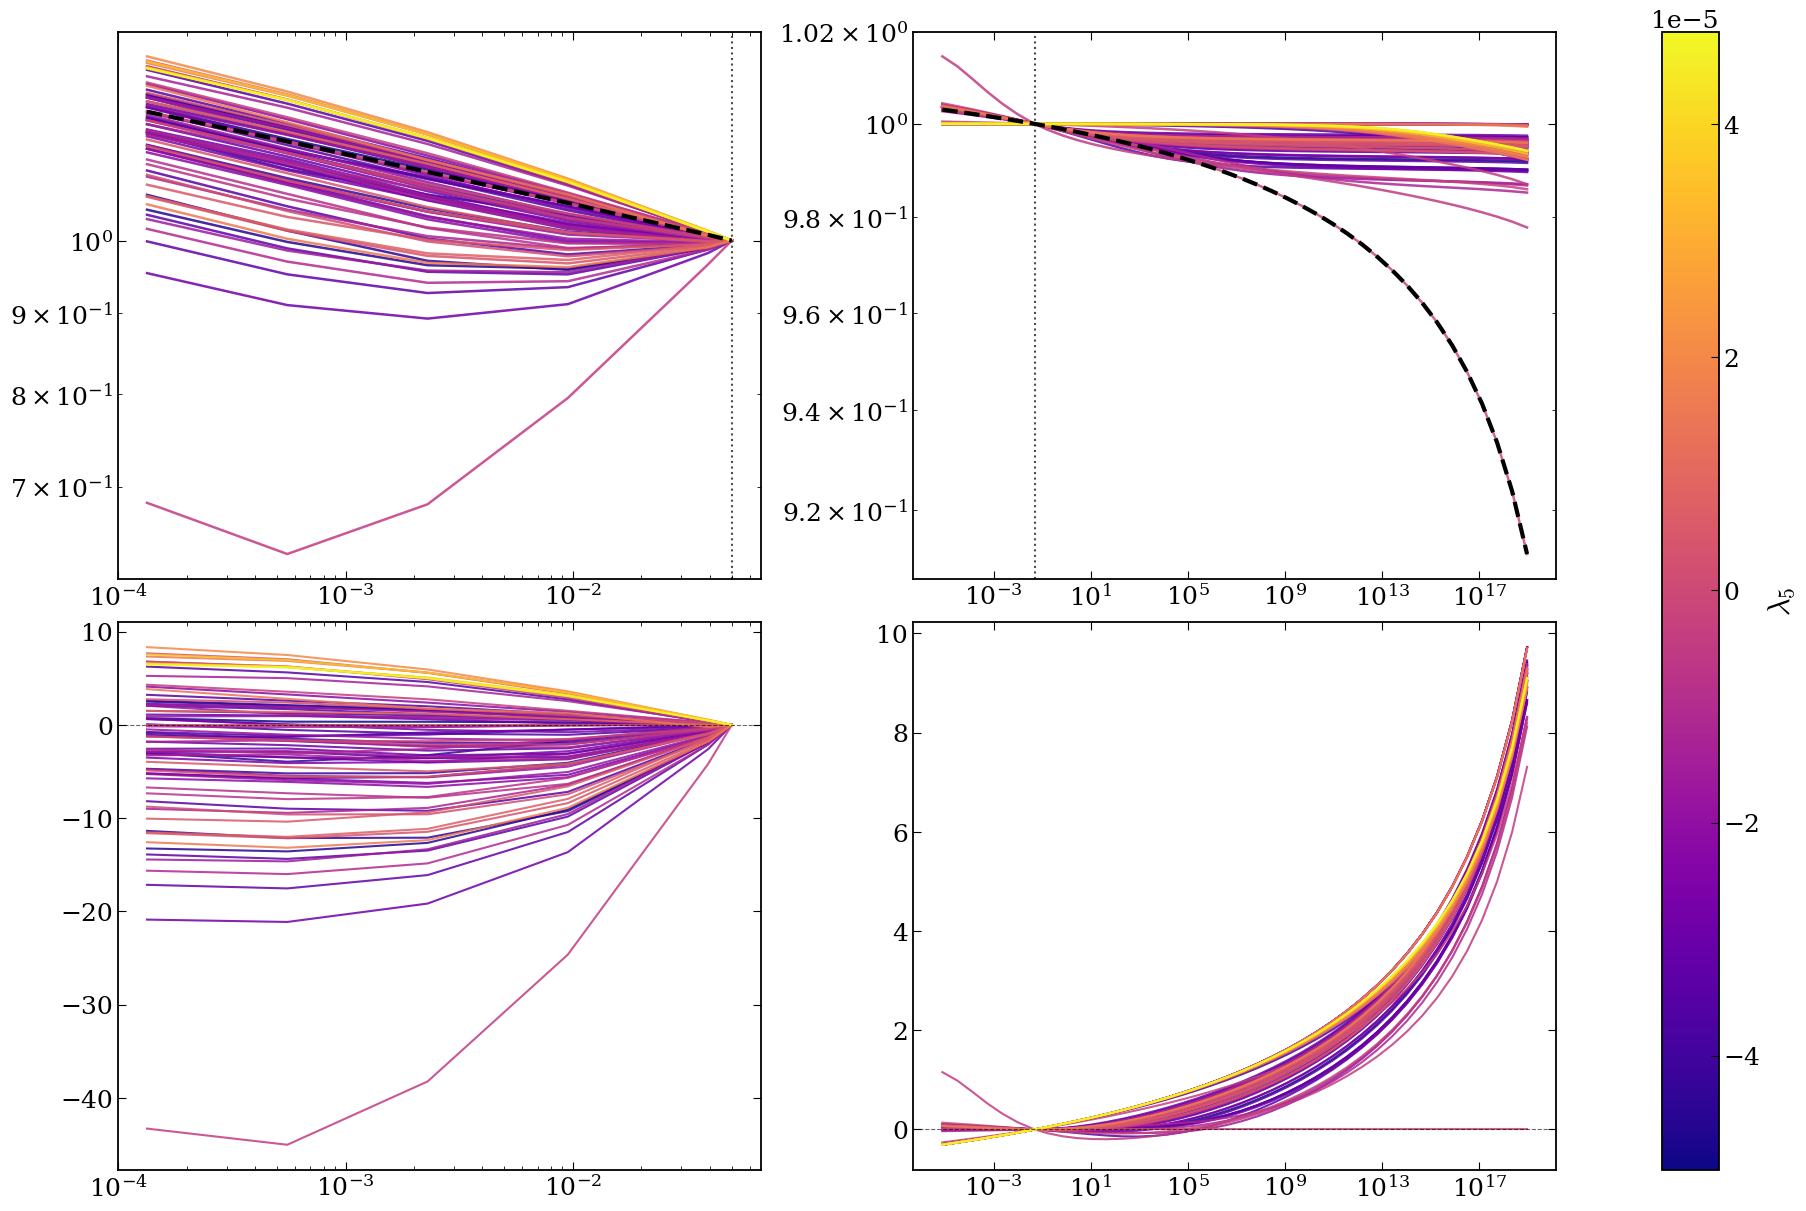

In [71]:
# stats_df, kept_df = plot_filtered_spectra_by_ns(
#     NEQS=7,
#     lamX_values=lam4_values,
#     baseX= 6.87065e-08,
#     base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
#     ns_min=0.967,
#     ns_max=0.971,
#     ns_target=0.967,
#     k_ref=0.05,
#     k_min_scalar=1e-4,
#     k_max_scalar=1e-1,
#     save_name="paper_higgs_truncation_neqs7_lam4_filtered_ns_spectra.pdf"
# )


stats_df, kept_df = plot_filtered_spectra_by_ns(
    NEQS=8,
    lamX_values=lam5_values,
    baseX= -8.92461e-9,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    ns_min=0.963,
    ns_max=0.971,
    ns_target=0.967,
    k_ref=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    save_name="paper_higgs_truncation_neqs8_lam5_filtered_ns_spectra.pdf"
)


#If we do neqs9 that is base at 6.1e-10



Let's look at the span of e-folds:

In [72]:
def plot_deltaN_histogram_neqs8(
    base_path_root,
    base8_value=-8.92461e-9,
    ns_min=None,
    ns_max=None,
    r_min=None,
    r_max=None,
    bins=30,
    save_name=None,
    show=True,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 13,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    NEQS = 8
    param = "lam5"

    summary_file = os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"neqs{NEQS}_summary.csv",
    )

    df = pd.read_csv(summary_file)

    # --------------------------------------------------------
    # Find reference/base model
    # --------------------------------------------------------
    base_row = df.loc[np.isclose(df[param], base8_value)]

    if len(base_row) == 0:
        raise ValueError(
            f"Could not find base {param}={base8_value:.10e} "
            f"in {summary_file}"
        )

    base_N_end = float(base_row.iloc[0]["original_N_end"])

    # --------------------------------------------------------
    # Compute deltaN
    # --------------------------------------------------------
    df["deltaN_from_base"] = (
        df["original_N_end"] - base_N_end
    )

    df["abs_deltaN_from_base"] = np.abs(
        df["deltaN_from_base"]
    )

    # --------------------------------------------------------
    # Apply cuts
    # --------------------------------------------------------
    if ns_min is not None:
        df = df[df["n_s"] >= ns_min].copy()

    if ns_max is not None:
        df = df[df["n_s"] <= ns_max].copy()

    if r_min is not None:
        df = df[df["r"] >= r_min].copy()

    if r_max is not None:
        df = df[df["r"] <= r_max].copy()

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    fig, ax = plt.subplots(
        figsize=(10, 6.5),
        constrained_layout=True,
    )

    ax.hist(
        df["deltaN_from_base"],
        bins=bins,
        color="mediumslateblue",
        alpha=0.78,
        edgecolor="black",
        linewidth=0.9,
    )

    ax.axvline(
        0.0,
        color="black",
        ls="--",
        lw=2.0,
        label="reference model",
    )

    ax.set_title(
        r"NEQS=8 $\lambda_5$ scan"
    )

    ax.set_xlabel(
        r"$\Delta N_{\rm end}"
        r"=N_{\rm end}-N_{\rm end,ref}$"
    )

    ax.set_ylabel("number of models")

    ax.grid(True, alpha=0.25)

    ax.legend(
        frameon=False,
        loc="upper right",
    )

    # --------------------------------------------------------
    # Figure title
    # --------------------------------------------------------
    title = (
        r"Distribution of inflationary-duration offsets "
        r"for NEQS=8"
    )

    cuts = []

    if ns_min is not None or ns_max is not None:
        cuts.append(
            rf"${ns_min} < n_s < {ns_max}$"
        )

    if r_min is not None or r_max is not None:
        cuts.append(
            rf"${r_min} < r < {r_max}$"
        )

    if len(cuts) > 0:
        title += "\n" + ", ".join(cuts)

    fig.suptitle(
        title,
        fontsize=20,
    )

    # --------------------------------------------------------
    # Print diagnostics
    # --------------------------------------------------------
    print("\n" + "=" * 70)
    print(r"NEQS=8, $\lambda_5$ scan")
    print("=" * 70)

    print(f"N models shown: {len(df)}")
    print(f"reference original_N_end = {base_N_end:.6f}")

    print("\nDeltaN statistics:")
    print(
        df["deltaN_from_base"]
        .describe()
        .to_string()
    )

    print("\nLargest |deltaN| models:")

    print(
        df[[
            param,
            "n_s",
            "r",
            "alpha_s",
            "original_N_end",
            "deltaN_from_base",
            "abs_deltaN_from_base",
        ]]
        .sort_values(
            "abs_deltaN_from_base",
            ascending=False,
        )
        .head(20)
        .to_string(index=False)
    )

    print("\nClosest-to-reference models:")

    print(
        df[[
            param,
            "n_s",
            "r",
            "alpha_s",
            "original_N_end",
            "deltaN_from_base",
            "abs_deltaN_from_base",
        ]]
        .sort_values(
            "abs_deltaN_from_base",
            ascending=True,
        )
        .head(20)
        .to_string(index=False)
    )

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------
    if save_name is None:
        save_name = (
            "deltaN_histogram_neqs8.png"
        )

#     plt.savefig(
#         save_name,
#         dpi=300,
#         bbox_inches="tight",
#     )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return df


NEQS=8, $\lambda_5$ scan
N models shown: 75
reference original_N_end = 946.349733

DeltaN statistics:
count     75.000000
mean     -18.651155
std       58.510857
min     -171.763345
25%       -8.311903
50%       -6.715682
75%       -0.665765
max       41.886857

Largest |deltaN| models:
         lam5      n_s            r   alpha_s  original_N_end  deltaN_from_base  abs_deltaN_from_base
-3.430502e-05 0.965781 1.078093e-06 -0.001259      774.586388       -171.763345            171.763345
-2.196824e-05 0.964381 1.073577e-06 -0.001241      774.655405       -171.694327            171.694327
 1.416172e-05 0.964303 2.994703e-06 -0.001287      782.333967       -164.015765            164.015765
-1.631449e-05 0.967537 1.607752e-06 -0.001274      783.444728       -162.905005            162.905005
-4.772679e-05 0.966867 8.788249e-07 -0.001289      784.517697       -161.832036            161.832036
-4.010833e-05 0.967038 8.441444e-07 -0.001302      788.405301       -157.944432            157.9444

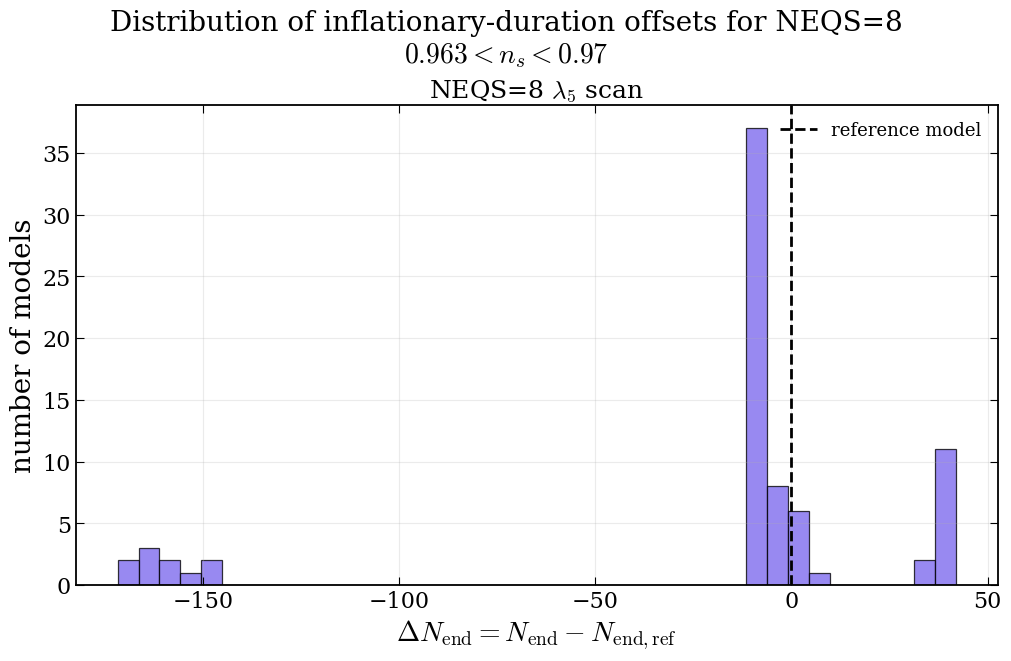

In [73]:
df8 = plot_deltaN_histogram_neqs8(
    base_path_root=base_path_root,
    base8_value=-8.92461e-9,
    ns_min=0.963,
    ns_max=0.97,
    r_min=None,
    r_max=None,
    bins=40,
    save_name="neqs8_deltaN_histogram.png",
)

Now, we can look at their backgrounds according to their original $N_end$ value

In [34]:
def plot_neqs8_background_and_spectra_by_Nend(
    base_path_root,
    lam5_values,
    ns_min=0.963,
    ns_max=0.970,
    k_ref=0.05,
    N_window=None,
    k_min_scalar=None,
    k_max_scalar=1e-1,
    cmap_name="plasma",
    save_name=None,
    show=True,
):
    NEQS = 8
    param_name = "lam5"

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 18,
        "axes.titlesize": 17,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 11,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    def sanitize(vals):
        return np.array(
            [x[0] if isinstance(x, tuple) else x for x in vals],
            dtype=float,
        )

    def folder_for(value):
        return os.path.join(
            base_path_root,
            "neqs8",
            f"lam5_{value:.10e}",
        )

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        order = np.argsort(x)
        return x[order], y[order]

    def normalize_at_ref(x, y, x_ref):
        x, y = prepare_increasing(x, y)

        if not (x.min() <= x_ref <= x.max()):
            raise ValueError(
                f"reference={x_ref} outside range [{x.min():.3e}, {x.max():.3e}]"
            )

        y_ref = np.interp(x_ref, x, y)

        if np.abs(y_ref) < 1e-30:
            raise ValueError(f"reference value too small at {x_ref}")

        return x, y / y_ref

    def apply_N_window(N, Y):
        if N_window is None:
            return N, Y

        Nmin, Nmax = N_window
        mask = (N >= Nmin) & (N <= Nmax)
        return N[mask], Y[mask]

    def scalar_k_mask(k):
        mask = np.ones_like(k, dtype=bool)

        if k_min_scalar is not None:
            mask &= k >= k_min_scalar

        if k_max_scalar is not None:
            mask &= k <= k_max_scalar

        return mask

    summary_file = os.path.join(
        base_path_root,
        "neqs8",
        "neqs8_summary.csv",
    )

    summary_df = pd.read_csv(summary_file)

    rows = []
    models = []

    for value in sanitize(lam5_values):
        try:
            row_match = summary_df.loc[
                np.isclose(summary_df[param_name], value)
            ]

            if len(row_match) == 0:
                print(f"Skipping lam5={value:.5e}: not in summary")
                continue

            row = row_match.iloc[0]

            ns = row["n_s"]
            r = row["r"]
            alpha_s = row["alpha_s"]
            N_end = row["original_N_end"]

            keep = ns_min <= ns <= ns_max

            rows.append({
                "lam5": value,
                "n_s": ns,
                "r": r,
                "alpha_s": alpha_s,
                "original_N_end": N_end,
                "kept_by_ns": keep,
            })

            if not keep:
                continue

            folder = folder_for(value)

            path_file = os.path.join(
                folder,
                f"path_neqs8_lam5_{value:.10e}.dat",
            )

            spec_s_file = os.path.join(
                folder,
                "spec_s_neqs8.dat",
            )

            spec_t_file = os.path.join(
                folder,
                "spec_t_neqs8.dat",
            )

            path = pd.read_csv(
                path_file,
                sep=r"\s+",
                header=None,
            ).values

            spec_s = np.loadtxt(spec_s_file)
            spec_t = np.loadtxt(spec_t_file)

            H = path[:, 1]
            eps = path[:, 2]
            N = path[:, NEQS]

            k_s = spec_s[:, 0]
            Ps = np.abs(spec_s[:, 1])

            k_t = spec_t[:, 0]
            Pt = np.abs(spec_t[:, 1])

            N_H, H_norm = normalize_at_ref(
                N,
                H,
                60.0,
            )

            N_eps, eps_norm = normalize_at_ref(
                N,
                eps,
                60.0,
            )

            N_H, H_norm = apply_N_window(
                N_H,
                H_norm,
            )

            N_eps, eps_norm = apply_N_window(
                N_eps,
                eps_norm,
            )

            k_s, Ps_norm = normalize_at_ref(
                k_s,
                Ps,
                k_ref,
            )

            k_t, Pt_norm = normalize_at_ref(
                k_t,
                Pt,
                k_ref,
            )

            mask_s = scalar_k_mask(k_s)

            models.append({
                "lam5": value,
                "n_s": ns,
                "r": r,
                "alpha_s": alpha_s,
                "original_N_end": N_end,

                "N_H": N_H,
                "H_norm": H_norm,
                "N_eps": N_eps,
                "eps_norm": eps_norm,

                "k_s": k_s[mask_s],
                "Ps_norm": Ps_norm[mask_s],
                "k_t": k_t,
                "Pt_norm": Pt_norm,
            })

        except FileNotFoundError:
            print(f"Missing files for lam5={value:.5e}")

        except ValueError as e:
            print(f"Skipping lam5={value:.5e}: {e}")

    stats_df = pd.DataFrame(rows)

    if len(models) == 0:
        print("No models passed the cuts.")
        return stats_df

    Nends = np.array([
        m["original_N_end"]
        for m in models
    ])

    cmap = plt.get_cmap(cmap_name)

    norm = mcolors.Normalize(
        vmin=Nends.min(),
        vmax=Nends.max(),
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(17, 11),
        constrained_layout=True,
    )

    ax_H, ax_eps = axes[0]
    ax_Ps, ax_Pt = axes[1]

    for m in models:
        color = cmap(
            norm(m["original_N_end"])
        )

        ax_H.plot(
            m["N_H"],
            m["H_norm"],
            color=color,
            lw=1.8,
            alpha=0.85,
        )

        ax_eps.plot(
            m["N_eps"],
            m["eps_norm"],
            color=color,
            lw=1.8,
            alpha=0.85,
        )

        ax_Ps.loglog(
            m["k_s"],
            m["Ps_norm"],
            color=color,
            lw=1.8,
            alpha=0.85,
        )

        ax_Pt.loglog(
            m["k_t"],
            m["Pt_norm"],
            color=color,
            lw=1.8,
            alpha=0.85,
        )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )

    cbar = fig.colorbar(
        sm,
        ax=axes,
        pad=0.02,
    )

    cbar.set_label(
        r"$N_{\rm end}$"
    )

    cbar.ax.tick_params(
        direction="in"
    )

    ax_H.set_title(
        r"Normalized Hubble evolution"
    )

    ax_eps.set_title(
        r"Normalized slow-roll evolution"
    )

    ax_Ps.set_title(
        r"Normalized scalar spectra"
    )

    ax_Pt.set_title(
        r"Normalized tensor spectra"
    )

    ax_H.set_xlabel(r"$N$")
    ax_eps.set_xlabel(r"$N$")
    ax_Ps.set_xlabel(r"$k$")
    ax_Pt.set_xlabel(r"$k$")

    ax_H.set_ylabel(r"$H/H(N=60)$")
    ax_eps.set_ylabel(r"$\epsilon/\epsilon(N=60)$")
    ax_Ps.set_ylabel(r"$P_s/P_s(k=0.05)$")
    ax_Pt.set_ylabel(r"$P_t/P_t(k=0.05)$")

    ax_H.invert_xaxis()
    ax_eps.invert_xaxis()

    ax_Ps.axvline(
        k_ref,
        color="black",
        ls=":",
        lw=1.2,
        alpha=0.7,
    )

    ax_Pt.axvline(
        k_ref,
        color="black",
        ls=":",
        lw=1.2,
        alpha=0.7,
    )

    if k_min_scalar is not None or k_max_scalar is not None:
        xmin = (
            k_min_scalar
            if k_min_scalar is not None
            else min([m["k_s"].min() for m in models])
        )

        xmax = (
            k_max_scalar
            if k_max_scalar is not None
            else max([m["k_s"].max() for m in models])
        )

        ax_Ps.set_xlim(
            xmin,
            xmax,
        )

    for ax in axes.ravel():
        ax.grid(
            True,
            which="major",
            alpha=0.25,
        )

        ax.grid(
            True,
            which="minor",
            alpha=0.12,
        )

        ax.minorticks_on()

    fig.suptitle(
        rf"NEQS=8 models with ${ns_min}\leq n_s\leq {ns_max}$, "
        rf"colored by $N_{{\rm end}}$",
        fontsize=22,
    )

    if save_name is None:
        save_name = "neqs8_background_and_spectra_by_Nend.png"

    plt.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    kept_df = pd.DataFrame([
        {
            "lam5": m["lam5"],
            "n_s": m["n_s"],
            "r": m["r"],
            "alpha_s": m["alpha_s"],
            "original_N_end": m["original_N_end"],
        }
        for m in models
    ]).sort_values("original_N_end")

    print("\n=== NEQS=8 kept models ===")
    print(f"Total models loaded: {len(stats_df)}")
    print(f"Models in ns window [{ns_min}, {ns_max}]: {len(kept_df)}")
    print(kept_df.to_string(index=False))

    return kept_df

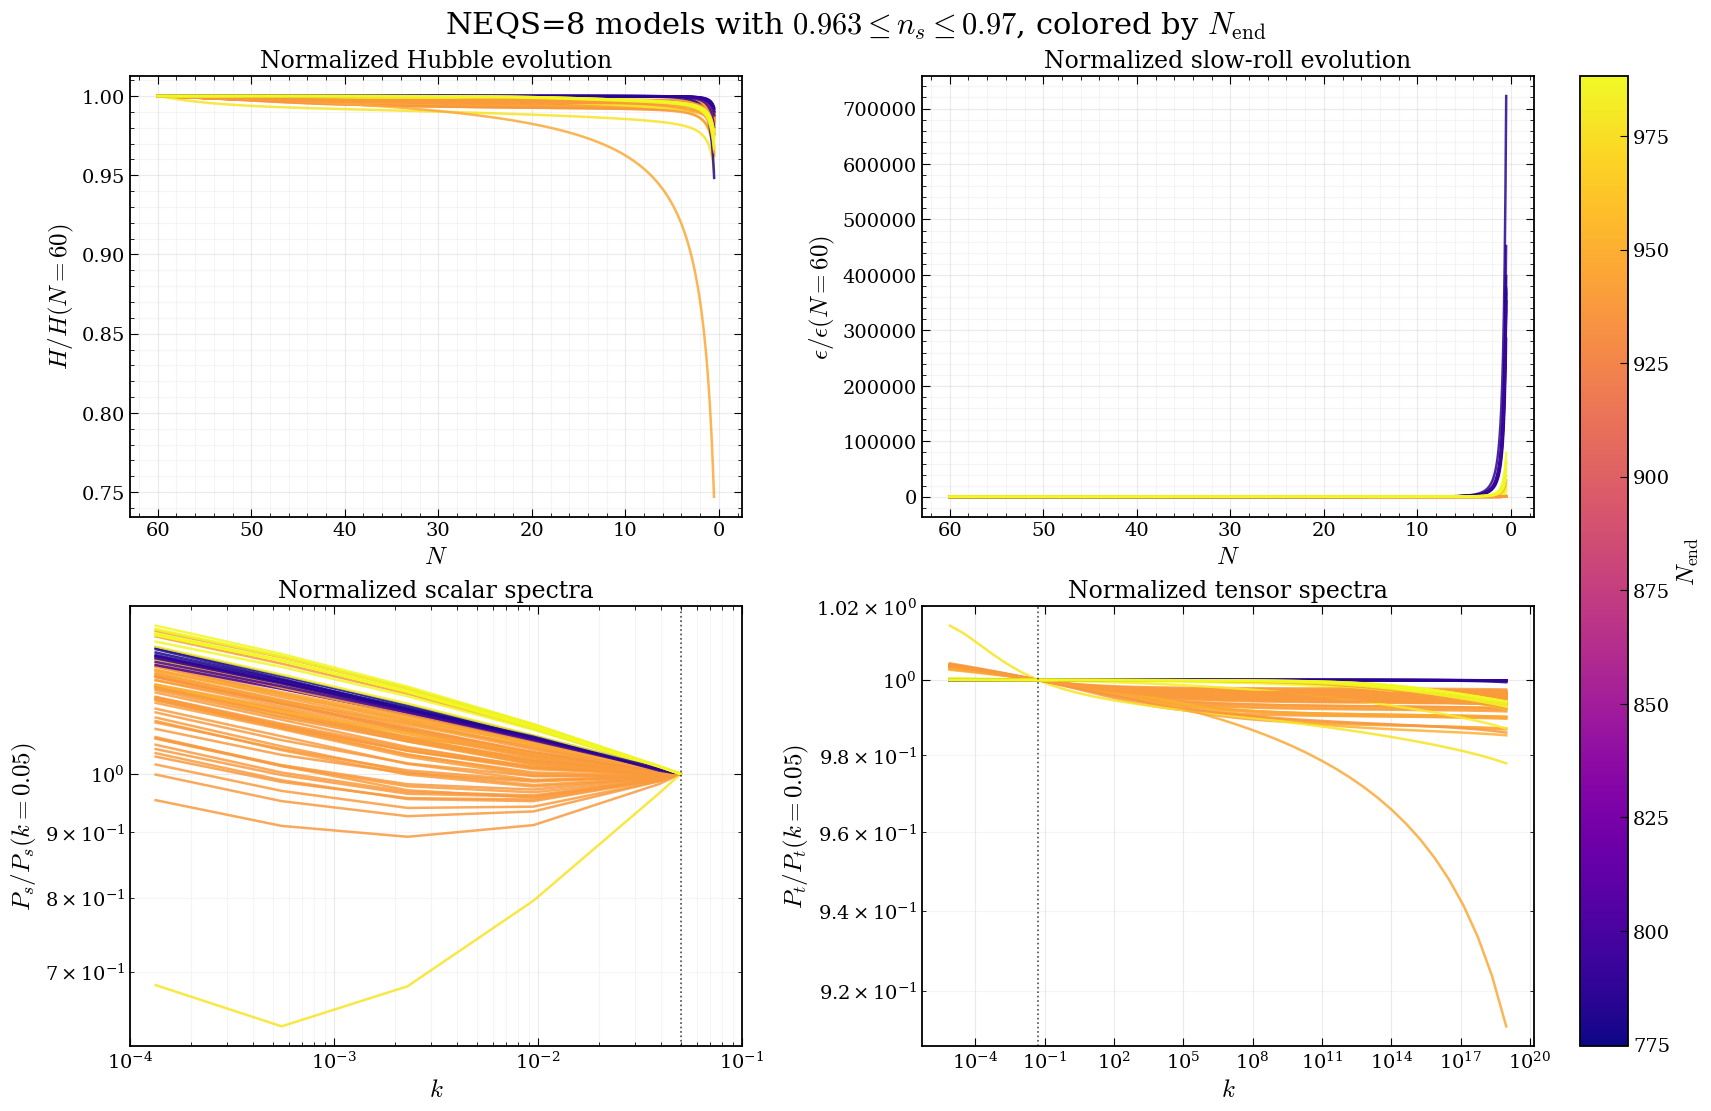


=== NEQS=8 kept models ===
Total models loaded: 75
Models in ns window [0.963, 0.97]: 75
         lam5      n_s            r   alpha_s  original_N_end
-3.430502e-05 0.965781 1.078093e-06 -0.001259      774.586388
-2.196824e-05 0.964381 1.073577e-06 -0.001241      774.655405
 1.416172e-05 0.964303 2.994703e-06 -0.001287      782.333967
-1.631449e-05 0.967537 1.607752e-06 -0.001274      783.444728
-4.772679e-05 0.966867 8.788249e-07 -0.001289      784.517697
-4.010833e-05 0.967038 8.441444e-07 -0.001302      788.405301
 1.625328e-06 0.966589 1.289507e-06 -0.001299      788.763992
-3.458956e-05 0.967485 6.587112e-07 -0.001336      795.075093
 1.128077e-05 0.968558 2.132658e-06 -0.001335      796.247984
-1.849235e-05 0.969488 1.194842e-06 -0.001339      796.755119
-2.522522e-06 0.966360 3.968736e-03  0.001085      935.041985
-2.520148e-05 0.966146 3.718381e-03  0.001473      936.940509
-2.635195e-05 0.965862 3.705654e-03  0.001223      937.056975
 4.901662e-06 0.968524 3.621119e-03  0.004

In [35]:
kept8_bg_df = plot_neqs8_background_and_spectra_by_Nend(
    base_path_root=base_path_root,
    lam5_values=lam5_values,
    ns_min=0.963,
    ns_max=0.970,
    k_ref=0.05,
    N_window=(0.5, 60),
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    save_name="neqs8_background_spectra_by_Nend.png",
)

Examining the same but with an r cut:

In [36]:
def plot_neqs8_background_and_spectra_by_Nend_with_r(
    base_path_root,
    lam5_values,
    ns_min=0.963,
    ns_max=0.970,
    r_min=None,
    r_max=None,
    k_ref=0.05,
    N_window=None,
    k_min_scalar=None,
    k_max_scalar=1e-1,
    cmap_name="plasma",
    save_name=None,
    show=True,
):
    NEQS = 8
    param_name = "lam5"

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 18,
        "axes.titlesize": 17,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 11,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    def sanitize(vals):
        return np.array(
            [x[0] if isinstance(x, tuple) else x for x in vals],
            dtype=float,
        )

    def folder_for(value):
        return os.path.join(
            base_path_root,
            "neqs8",
            f"lam5_{value:.10e}",
        )

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        order = np.argsort(x)
        return x[order], y[order]

    def normalize_at_ref(x, y, x_ref):
        x, y = prepare_increasing(x, y)

        if not (x.min() <= x_ref <= x.max()):
            raise ValueError(
                f"reference={x_ref} outside range [{x.min():.3e}, {x.max():.3e}]"
            )

        y_ref = np.interp(x_ref, x, y)

        if np.abs(y_ref) < 1e-30:
            raise ValueError(f"reference value too small at {x_ref}")

        return x, y / y_ref

    def apply_N_window(N, Y):
        if N_window is None:
            return N, Y

        Nmin, Nmax = N_window
        mask = (N >= Nmin) & (N <= Nmax)
        return N[mask], Y[mask]

    def scalar_k_mask(k):
        mask = np.ones_like(k, dtype=bool)

        if k_min_scalar is not None:
            mask &= k >= k_min_scalar

        if k_max_scalar is not None:
            mask &= k <= k_max_scalar

        return mask

    summary_file = os.path.join(
        base_path_root,
        "neqs8",
        "neqs8_summary.csv",
    )

    summary_df = pd.read_csv(summary_file)

    rows = []
    models = []

    for value in sanitize(lam5_values):
        try:
            row_match = summary_df.loc[
                np.isclose(summary_df[param_name], value)
            ]

            if len(row_match) == 0:
                print(f"Skipping lam5={value:.5e}: not in summary")
                continue

            row = row_match.iloc[0]

            ns = row["n_s"]
            r = row["r"]
            alpha_s = row["alpha_s"]
            N_end = row["original_N_end"]

            keep_ns = ns_min <= ns <= ns_max

            keep_r = True

            if r_min is not None and r < r_min:
                keep_r = False

            if r_max is not None and r > r_max:
                keep_r = False

            keep = keep_ns and keep_r

            rows.append({
                "lam5": value,
                "n_s": ns,
                "r": r,
                "alpha_s": alpha_s,
                "original_N_end": N_end,
                "kept_by_ns": keep_ns,
                "kept_by_r": keep_r,
                "kept": keep,
            })

            if not keep:
                continue

            folder = folder_for(value)

            path_file = os.path.join(
                folder,
                f"path_neqs8_lam5_{value:.10e}.dat",
            )

            spec_s_file = os.path.join(
                folder,
                "spec_s_neqs8.dat",
            )

            spec_t_file = os.path.join(
                folder,
                "spec_t_neqs8.dat",
            )

            path = pd.read_csv(
                path_file,
                sep=r"\s+",
                header=None,
            ).values

            spec_s = np.loadtxt(spec_s_file)
            spec_t = np.loadtxt(spec_t_file)

            H = path[:, 1]
            eps = path[:, 2]
            N = path[:, NEQS]

            k_s = spec_s[:, 0]
            Ps = np.abs(spec_s[:, 1])

            k_t = spec_t[:, 0]
            Pt = np.abs(spec_t[:, 1])

            N_H, H_norm = normalize_at_ref(N, H, 60.0)
            N_eps, eps_norm = normalize_at_ref(N, eps, 60.0)

            N_H, H_norm = apply_N_window(N_H, H_norm)
            N_eps, eps_norm = apply_N_window(N_eps, eps_norm)

            k_s, Ps_norm = normalize_at_ref(k_s, Ps, k_ref)
            k_t, Pt_norm = normalize_at_ref(k_t, Pt, k_ref)

            mask_s = scalar_k_mask(k_s)

            models.append({
                "lam5": value,
                "n_s": ns,
                "r": r,
                "alpha_s": alpha_s,
                "original_N_end": N_end,

                "N_H": N_H,
                "H_norm": H_norm,
                "N_eps": N_eps,
                "eps_norm": eps_norm,

                "k_s": k_s[mask_s],
                "Ps_norm": Ps_norm[mask_s],
                "k_t": k_t,
                "Pt_norm": Pt_norm,
            })

        except FileNotFoundError:
            print(f"Missing files for lam5={value:.5e}")

        except ValueError as e:
            print(f"Skipping lam5={value:.5e}: {e}")

    stats_df = pd.DataFrame(rows)

    if len(models) == 0:
        print("No models passed the cuts.")
        return stats_df

    Nends = np.array([m["original_N_end"] for m in models])

    cmap = plt.get_cmap(cmap_name)
    norm = mcolors.Normalize(vmin=Nends.min(), vmax=Nends.max())

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(17, 11),
        constrained_layout=True,
    )

    ax_H, ax_eps = axes[0]
    ax_Ps, ax_Pt = axes[1]

    for m in models:
        color = cmap(norm(m["original_N_end"]))

        ax_H.plot(m["N_H"], m["H_norm"], color=color, lw=1.8, alpha=0.85)
        ax_eps.plot(m["N_eps"], m["eps_norm"], color=color, lw=1.8, alpha=0.85)
        ax_Ps.loglog(m["k_s"], m["Ps_norm"], color=color, lw=1.8, alpha=0.85)
        ax_Pt.loglog(m["k_t"], m["Pt_norm"], color=color, lw=1.8, alpha=0.85)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=axes, pad=0.02)
    cbar.set_label(r"$N_{\rm end}$")
    cbar.ax.tick_params(direction="in")

    ax_H.set_title(r"Normalized Hubble evolution")
    ax_eps.set_title(r"Normalized slow-roll evolution")
    ax_Ps.set_title(r"Normalized scalar spectra")
    ax_Pt.set_title(r"Normalized tensor spectra")

    ax_H.set_xlabel(r"$N$")
    ax_eps.set_xlabel(r"$N$")
    ax_Ps.set_xlabel(r"$k$")
    ax_Pt.set_xlabel(r"$k$")

    ax_H.set_ylabel(r"$H/H(N=60)$")
    ax_eps.set_ylabel(r"$\epsilon/\epsilon(N=60)$")
    ax_Ps.set_ylabel(r"$P_s/P_s(k=0.05)$")
    ax_Pt.set_ylabel(r"$P_t/P_t(k=0.05)$")

    ax_H.invert_xaxis()
    ax_eps.invert_xaxis()

    ax_Ps.axvline(k_ref, color="black", ls=":", lw=1.2, alpha=0.7)
    ax_Pt.axvline(k_ref, color="black", ls=":", lw=1.2, alpha=0.7)

    if k_min_scalar is not None or k_max_scalar is not None:
        xmin = (
            k_min_scalar
            if k_min_scalar is not None
            else min([m["k_s"].min() for m in models])
        )

        xmax = (
            k_max_scalar
            if k_max_scalar is not None
            else max([m["k_s"].max() for m in models])
        )

        ax_Ps.set_xlim(xmin, xmax)

    for ax in axes.ravel():
        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()

    cut_text = rf"${ns_min}\leq n_s\leq {ns_max}$"

    if r_min is not None or r_max is not None:
        rmin_text = r_min if r_min is not None else 0.0
        rmax_text = r_max if r_max is not None else np.inf
        cut_text += rf", ${rmin_text:.1e}\leq r\leq {rmax_text:.1e}$"

    fig.suptitle(
        rf"NEQS=8 models with {cut_text}, colored by $N_{{\rm end}}$",
        fontsize=22,
    )

    if save_name is None:
        save_name = "neqs8_background_and_spectra_by_Nend.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    kept_df = pd.DataFrame([
        {
            "lam5": m["lam5"],
            "n_s": m["n_s"],
            "r": m["r"],
            "alpha_s": m["alpha_s"],
            "original_N_end": m["original_N_end"],
        }
        for m in models
    ]).sort_values("original_N_end")

    print("\n=== NEQS=8 kept models ===")
    print(f"Total models loaded: {len(stats_df)}")
    print(f"Models passing ns cut [{ns_min}, {ns_max}]: {stats_df['kept_by_ns'].sum()}")
    print(f"Models passing r cut: {stats_df['kept_by_r'].sum()}")
    print(f"Models passing both cuts: {len(kept_df)}")
    print(kept_df.to_string(index=False))

    return kept_df

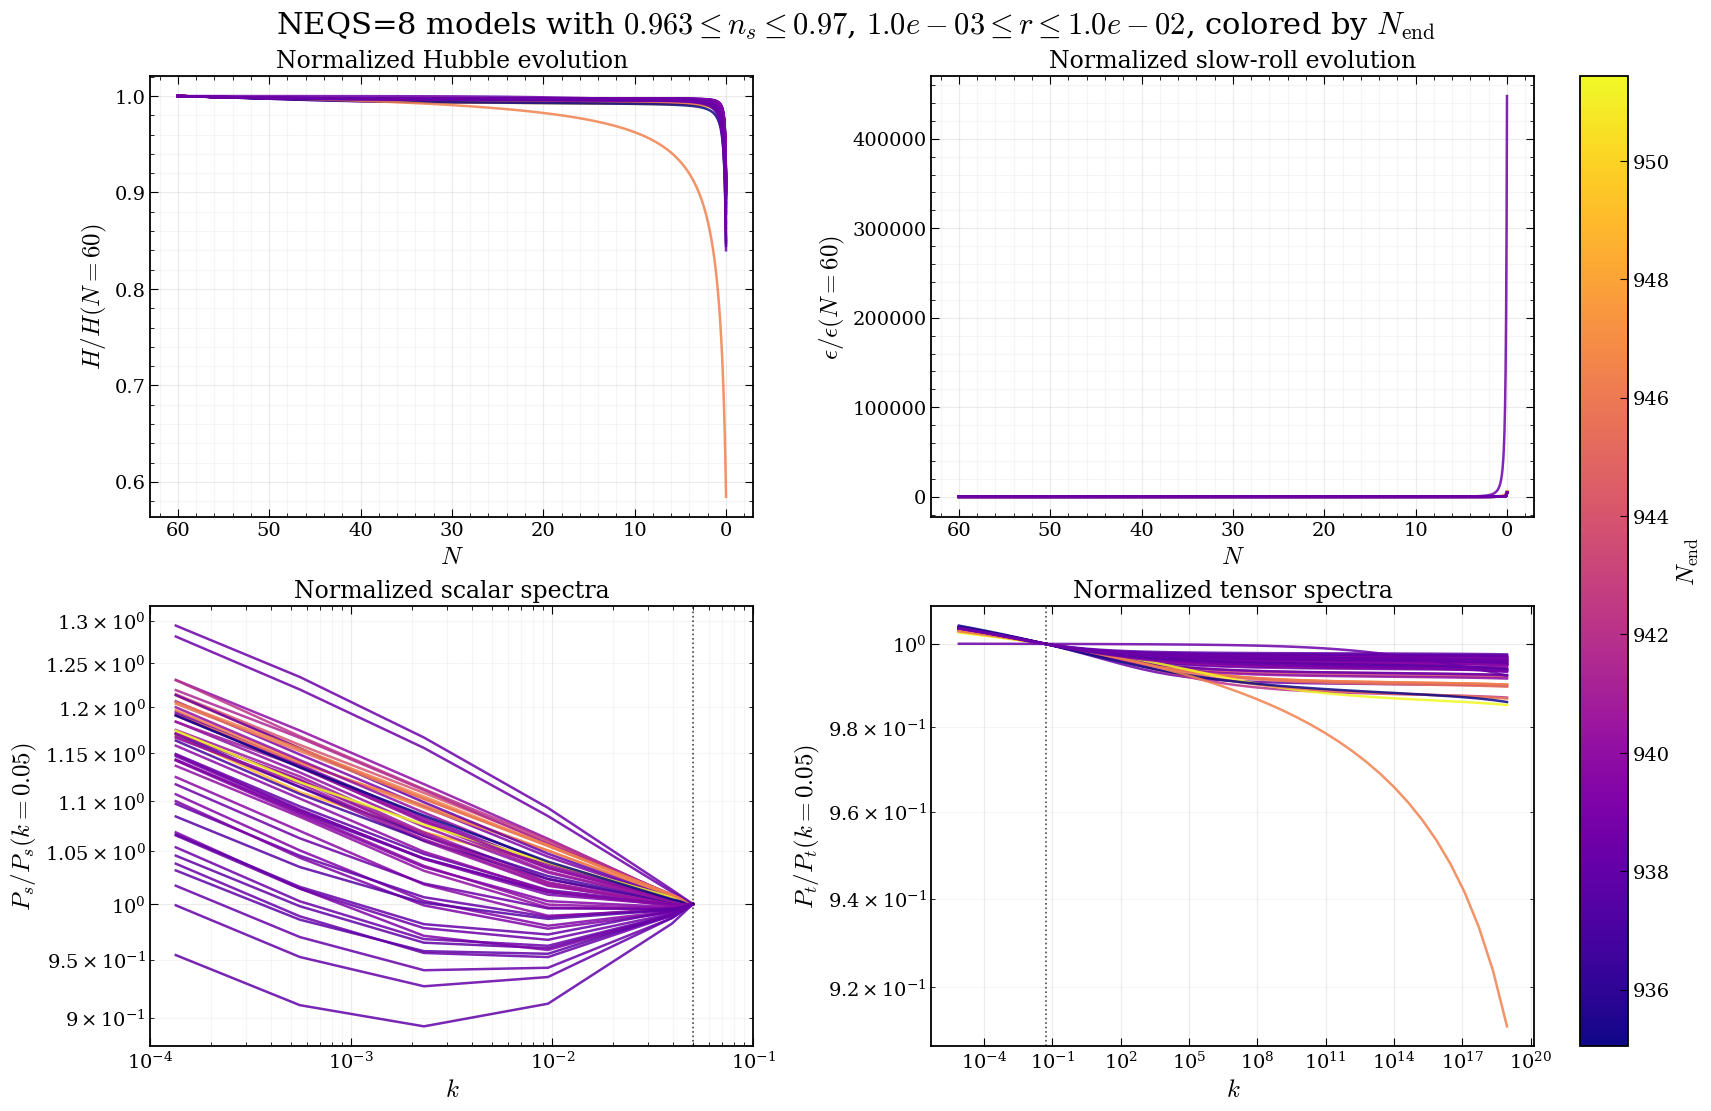


=== NEQS=8 kept models ===
Total models loaded: 75
Models passing ns cut [0.963, 0.97]: 75
Models passing r cut: 53
Models passing both cuts: 53
         lam5      n_s        r   alpha_s  original_N_end
-2.522522e-06 0.966360 0.003969  0.001085      935.041985
-2.520148e-05 0.966146 0.003718  0.001473      936.940509
-2.635195e-05 0.965862 0.003706  0.001223      937.056975
 4.901662e-06 0.968524 0.003621  0.004663      937.574332
-3.695693e-05 0.966138 0.003621  0.001868      937.708290
-1.636978e-05 0.968670 0.003586  0.006228      937.827201
-4.596396e-05 0.967691 0.003581  0.005178      937.916607
-2.940441e-05 0.969653 0.003559  0.009249      937.961586
-4.231030e-05 0.965699 0.003585  0.001449      938.021732
-3.243509e-05 0.968167 0.003559  0.007127      938.053928
-1.310223e-05 0.966605 0.003570  0.003534      938.081292
 7.047338e-06 0.967207 0.003565  0.004855      938.081375
-1.082379e-05 0.967231 0.003547  0.006213      938.199333
-3.347625e-05 0.966653 0.003545  0.005169 

In [38]:
kept8_bg_df = plot_neqs8_background_and_spectra_by_Nend_with_r(
    base_path_root=base_path_root,
    lam5_values=lam5_values,
    ns_min=0.963,
    ns_max=0.970,
    r_min=1e-3,
    r_max=1e-2,
    k_ref=0.05,
    N_window=(0, 60),
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    save_name="neqs8_background_spectra_by_Nend_mid_r_branch.png",
)


NEQS=8, $\lambda_5$ scan
N models shown: 30
reference original_N_end = 946.349733

DeltaN statistics:
count    30.000000
mean     -5.871774
std       3.610261
min     -11.307748
25%      -8.288964
50%      -6.331861
75%      -5.797618
max       5.084914

Largest |deltaN| models:
     lam5      n_s        r   alpha_s  original_N_end  deltaN_from_base  abs_deltaN_from_base
-0.000003 0.966360 0.003969  0.001085      935.041985        -11.307748             11.307748
-0.000025 0.966146 0.003718  0.001473      936.940509         -9.409224              9.409224
 0.000005 0.968524 0.003621  0.004663      937.574332         -8.775401              8.775401
-0.000037 0.966138 0.003621  0.001868      937.708290         -8.641443              8.641443
-0.000016 0.968670 0.003586  0.006228      937.827201         -8.522532              8.522532
-0.000046 0.967691 0.003581  0.005178      937.916607         -8.433126              8.433126
-0.000029 0.969653 0.003559  0.009249      937.961586        

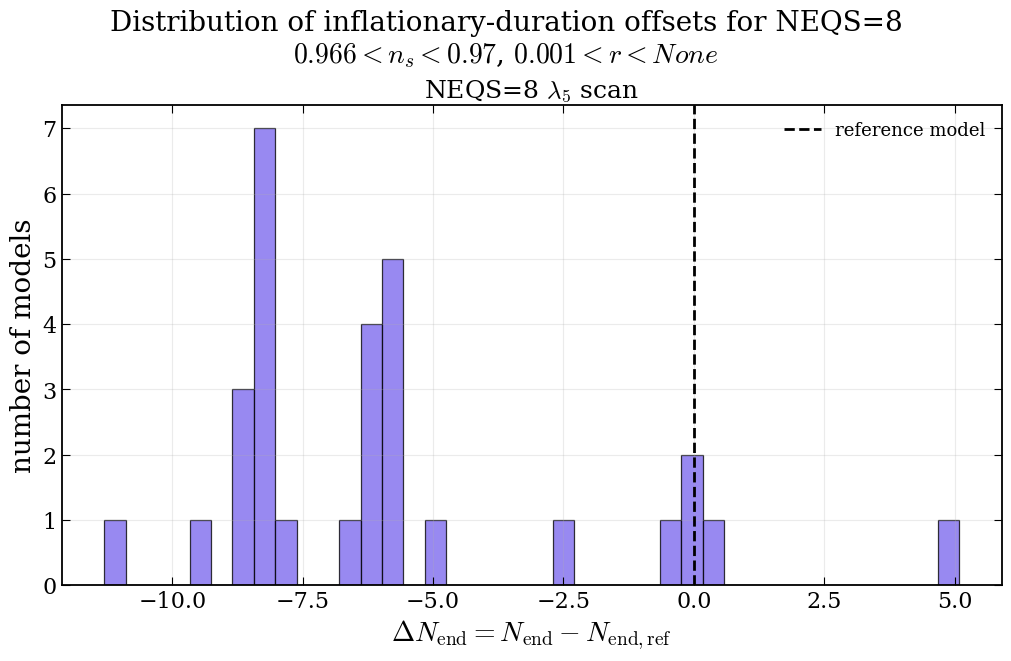

In [100]:
df8 = plot_deltaN_histogram_neqs8(
    base_path_root=base_path_root,
    base8_value=-8.92461e-9,
    ns_min=0.966,
    ns_max=0.97,
    r_min=1e-3,
    r_max=None,
    bins=40,
    save_name="neqs8_deltaN_histogram.png",
)

In [43]:
def plot_valid_ns_before_after_kshift_envelopes_rminmax(
    base_path_root,
    lam_values_by_neqs,
    ref_NEQS=8,
    ref_param="lam5",
    ref_value=6.87065e-8,
    ns_min=0.963,
    ns_max=0.970,
    r_min=None,
    r_max=None,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    max_abs_deltaN=None,
    tolerance=5.0,
    skip_zero=True,
    zero_tol=1e-30,
    save_name=None,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 18,
        "axes.titlesize": 17,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 11,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    colors_by_neqs = {
        7: "plum",
        8: "mediumslateblue",
        9: "royalblue",
    }

    def folder_for(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )

    def load_specs(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def load_observables(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)
        arr = np.loadtxt(os.path.join(folder, f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]

    def get_original_N_end(NEQS, param_name, value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)
        matches = summary_df.loc[np.isclose(summary_df[param_name], value)]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for NEQS={NEQS}, "
                f"{param_name}={value:.10e}"
            )

        return float(matches.iloc[0]["original_N_end"])

    def normalize_at_k(k, P, k_ref):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside range [{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(f"Reference spectrum too small at k={k_ref}")

        return k, P / P_ref

    def frac_on_ref_grid(
        k_ref_grid,
        P_ref_norm,
        k_cmp,
        P_cmp_norm,
        kmin=None,
        kmax=None,
    ):
        k_ref_grid, P_ref_norm = prepare_increasing(k_ref_grid, P_ref_norm)
        k_cmp, P_cmp_norm = prepare_increasing(k_cmp, P_cmp_norm)

        xmin = max(k_ref_grid.min(), k_cmp.min())
        xmax = min(k_ref_grid.max(), k_cmp.max())

        if kmin is not None:
            xmin = max(xmin, kmin)

        if kmax is not None:
            xmax = min(xmax, kmax)

        if xmin >= xmax:
            return np.array([]), np.array([])

        mask = (k_ref_grid >= xmin) & (k_ref_grid <= xmax)
        k_use = k_ref_grid[mask]

        if len(k_use) == 0:
            return np.array([]), np.array([])

        P_ref_use = P_ref_norm[mask]
        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp_norm)

        frac = (P_cmp_interp - P_ref_use) / P_ref_use

        return k_use, frac

    def collect_envelope(frac_curves, k_ref_grid):
        if len(frac_curves) == 0:
            return None, None, None

        k_env = k_ref_grid.copy()
        frac_stack = []

        for k_curve, frac_curve in frac_curves:
            if len(k_curve) < 2:
                continue

            interp = np.interp(
                k_env,
                k_curve,
                frac_curve,
                left=np.nan,
                right=np.nan,
            )

            if np.all(~np.isfinite(interp)):
                continue

            frac_stack.append(interp)

        if len(frac_stack) == 0:
            return None, None, None

        frac_stack = np.array(frac_stack)

        valid_cols = np.any(np.isfinite(frac_stack), axis=0)
        frac_stack = frac_stack[:, valid_cols]
        k_env = k_env[valid_cols]

        abs_stack = np.abs(frac_stack)

        mean_abs = 100.0 * np.nanmean(abs_stack, axis=0)
        max_abs = 100.0 * np.nanmax(abs_stack, axis=0)

        return k_env, mean_abs, max_abs

    # Reference spectra
    ref_N_end = get_original_N_end(ref_NEQS, ref_param, ref_value)

    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs(
        ref_NEQS,
        ref_param,
        ref_value,
    )

    k_s_ref, Ps_ref_norm = normalize_at_k(k_s_ref_raw, Ps_ref_raw, k_norm)
    k_t_ref, Pt_ref_norm = normalize_at_k(k_t_ref_raw, Pt_ref_raw, k_norm)

    curves = {
        NEQS: {
            "Ps_unshift": [],
            "Ps_shift": [],
            "Pt_unshift": [],
            "Pt_shift": [],
            "rows": [],
            "skipped_deltaN": 0,
            "skipped_ns": 0,
            "skipped_r": 0,
            "skipped_other": 0,
        }
        for NEQS in lam_values_by_neqs.keys()
    }

    for NEQS, lam_values in lam_values_by_neqs.items():
        param_name, _ = SCAN_INFO[NEQS]

        for item in lam_values:
            value = item[0] if isinstance(item, tuple) else item
            value = float(value)

            if skip_zero and np.isclose(value, 0.0, atol=zero_tol):
                continue

            try:
                r, ns, alpha_s = load_observables(NEQS, param_name, value)

                if not (ns_min <= ns <= ns_max):
                    curves[NEQS]["skipped_ns"] += 1
                    continue

                if r_min is not None and r < r_min:
                    curves[NEQS]["skipped_r"] += 1
                    continue

                if r_max is not None and r > r_max:
                    curves[NEQS]["skipped_r"] += 1
                    continue

                model_N_end = get_original_N_end(NEQS, param_name, value)
                deltaN = model_N_end - ref_N_end
                abs_deltaN = np.abs(deltaN)

                if max_abs_deltaN is not None and abs_deltaN > max_abs_deltaN:
                    curves[NEQS]["skipped_deltaN"] += 1
                    continue

                k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(
                    NEQS,
                    param_name,
                    value,
                )

                # Unshifted comparison
                k_s_un, Ps_un = normalize_at_k(k_s_raw, Ps_raw, k_norm)
                k_t_un, Pt_un = normalize_at_k(k_t_raw, Pt_raw, k_norm)

                k_ps_un, frac_ps_un = frac_on_ref_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s_un,
                    Ps_un,
                    kmin=k_min_scalar,
                    kmax=k_max_scalar,
                )

                k_pt_un, frac_pt_un = frac_on_ref_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t_un,
                    Pt_un,
                )

                # Shifted comparison
                k_s_shifted = k_s_raw * np.exp(-deltaN)
                k_t_shifted = k_t_raw * np.exp(-deltaN)

                k_s_sh, Ps_sh = normalize_at_k(k_s_shifted, Ps_raw, k_norm)
                k_t_sh, Pt_sh = normalize_at_k(k_t_shifted, Pt_raw, k_norm)

                k_ps_sh, frac_ps_sh = frac_on_ref_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s_sh,
                    Ps_sh,
                    kmin=k_min_scalar,
                    kmax=k_max_scalar,
                )

                k_pt_sh, frac_pt_sh = frac_on_ref_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t_sh,
                    Pt_sh,
                )

                if (
                    len(frac_ps_un) == 0
                    or len(frac_ps_sh) == 0
                    or len(frac_pt_un) == 0
                    or len(frac_pt_sh) == 0
                ):
                    curves[NEQS]["skipped_other"] += 1
                    continue

                curves[NEQS]["Ps_unshift"].append((k_ps_un, frac_ps_un))
                curves[NEQS]["Ps_shift"].append((k_ps_sh, frac_ps_sh))
                curves[NEQS]["Pt_unshift"].append((k_pt_un, frac_pt_un))
                curves[NEQS]["Pt_shift"].append((k_pt_sh, frac_pt_sh))

                curves[NEQS]["rows"].append({
                    "NEQS": NEQS,
                    "param_name": param_name,
                    "value": value,
                    "r": r,
                    "ns": ns,
                    "alpha_s": alpha_s,
                    "original_N_end": model_N_end,
                    "deltaN_from_ref_base": deltaN,
                    "abs_deltaN_from_ref_base": abs_deltaN,
                    "k_min_scalar": k_min_scalar,
                    "k_max_scalar": k_max_scalar,
                    "max_abs_deltaN_cut": max_abs_deltaN,

                    "max_Ps_unshift_pct": 100.0 * np.nanmax(np.abs(frac_ps_un)),
                    "max_Ps_shift_pct": 100.0 * np.nanmax(np.abs(frac_ps_sh)),
                    "max_Pt_unshift_pct": 100.0 * np.nanmax(np.abs(frac_pt_un)),
                    "max_Pt_shift_pct": 100.0 * np.nanmax(np.abs(frac_pt_sh)),

                    "mean_Ps_unshift_pct": 100.0 * np.nanmean(np.abs(frac_ps_un)),
                    "mean_Ps_shift_pct": 100.0 * np.nanmean(np.abs(frac_ps_sh)),
                    "mean_Pt_unshift_pct": 100.0 * np.nanmean(np.abs(frac_pt_un)),
                    "mean_Pt_shift_pct": 100.0 * np.nanmean(np.abs(frac_pt_sh)),
                })

            except FileNotFoundError:
                print(f"Missing files for NEQS={NEQS}, {param_name}={value:.5e}")
                curves[NEQS]["skipped_other"] += 1

            except ValueError as e:
                print(f"Skipping NEQS={NEQS}, {param_name}={value:.5e}: {e}")
                curves[NEQS]["skipped_other"] += 1

    # Plot
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 10.5),
        constrained_layout=True,
    )

    ax_ps_un, ax_ps_sh = axes[0]
    ax_pt_un, ax_pt_sh = axes[1]

    plot_specs = [
        ("Ps_unshift", ax_ps_un, k_s_ref, k_min_scalar, k_max_scalar, r"$P_s$", "Before $k$-shift"),
        ("Ps_shift", ax_ps_sh, k_s_ref, k_min_scalar, k_max_scalar, r"$P_s$", r"After $k \to k e^{-\Delta N}$"),
        ("Pt_unshift", ax_pt_un, k_t_ref, None, None, r"$P_t$", "Before $k$-shift"),
        ("Pt_shift", ax_pt_sh, k_t_ref, None, None, r"$P_t$", r"After $k \to k e^{-\Delta N}$"),
    ]

    envelope_rows = []

    for key, ax, k_ref_grid, kmin, kmax, quantity_label, title_suffix in plot_specs:
        for NEQS in lam_values_by_neqs.keys():
            color = colors_by_neqs.get(NEQS, None)

            k_env, mean_abs, max_abs = collect_envelope(
                curves[NEQS][key],
                k_ref_grid,
            )

            if k_env is None:
                continue

            mask = np.ones_like(k_env, dtype=bool)

            if kmin is not None:
                mask &= k_env >= kmin

            if kmax is not None:
                mask &= k_env <= kmax

            k_env = k_env[mask]
            mean_abs = mean_abs[mask]
            max_abs = max_abs[mask]

            if len(k_env) == 0:
                continue

            ax.plot(
                k_env,
                mean_abs,
                color=color,
                lw=2.2,
                label=rf"NEQS={NEQS} mean",
            )

            ax.fill_between(
                k_env,
                0.0,
                max_abs,
                color=color,
                alpha=0.20,
                label=rf"NEQS={NEQS} max",
            )

            envelope_rows.append({
                "NEQS": NEQS,
                "case": key,
                "n_models": len(curves[NEQS][key]),
                "median_mean_abs_pct": np.nanmedian(mean_abs),
                "max_envelope_pct": np.nanmax(max_abs),
                "k_min_scalar": k_min_scalar if "Ps" in key else np.nan,
                "k_max_scalar": k_max_scalar if "Ps" in key else np.nan,
                "max_abs_deltaN_cut": max_abs_deltaN,
                "r_min": r_min,
                "r_max": r_max,
            })

        ax.axhline(
            tolerance,
            color="black",
            lw=1.7,
            ls="--",
            label=rf"{tolerance:.0f}% tolerance",
        )

        ax.text(
            0.97,
            0.92,
            rf"{tolerance:.0f}% tolerance",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=11,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.80,
            ),
        )

        ax.set_xscale("log")

        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()

        ax.set_title(rf"{quantity_label} error envelope: {title_suffix}")
        ax.set_xlabel(r"$k$")
        ax.set_ylabel(rf"$|\Delta {quantity_label}/{quantity_label}|$ [\%]")

        if kmin is not None or kmax is not None:
            xmin = kmin if kmin is not None else k_ref_grid.min()
            xmax = kmax if kmax is not None else k_ref_grid.max()
            ax.set_xlim(xmin, xmax)

        ax.legend(
            fontsize=9,
            frameon=False,
            loc="best",
        )

    cut_text = ""

    if max_abs_deltaN is not None:
        cut_text += rf", $|\Delta N| \leq {max_abs_deltaN}$"

    if k_min_scalar is not None or k_max_scalar is not None:
        kmin_text = k_min_scalar if k_min_scalar is not None else k_s_ref.min()
        kmax_text = k_max_scalar if k_max_scalar is not None else k_s_ref.max()
        cut_text += rf", scalar $k\in[{kmin_text:.0e},{kmax_text:.0e}]$"

    if r_min is not None or r_max is not None:
        rmin_text = r_min if r_min is not None else 0.0
        rmax_text = r_max if r_max is not None else np.inf
        cut_text += rf", $r\in[{rmin_text:.2g},{rmax_text:.2g}]$"

    fig.suptitle(
        rf"Valid-$n_s$ spectral-error envelopes relative to NEQS={ref_NEQS} base "
        rf"(${ns_min}<n_s<{ns_max}$){cut_text}",
        fontsize=20,
    )

    if save_name is None:
        save_name = (
            f"valid_ns_r_error_envelopes_before_after_shift_"
            f"ref_neqs{ref_NEQS}.png"
        )

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    model_rows = []
    for NEQS in lam_values_by_neqs.keys():
        model_rows.extend(curves[NEQS]["rows"])

    model_df = pd.DataFrame(model_rows)
    envelope_df = pd.DataFrame(envelope_rows)

    print("\n=== Cut summary ===")
    for NEQS in lam_values_by_neqs.keys():
        print(
            f"NEQS={NEQS}: kept={len(curves[NEQS]['rows'])}, "
            f"skipped_ns={curves[NEQS]['skipped_ns']}, "
            f"skipped_r={curves[NEQS]['skipped_r']}, "
            f"skipped_deltaN={curves[NEQS]['skipped_deltaN']}, "
            f"skipped_other={curves[NEQS]['skipped_other']}"
        )

    print("\n=== Envelope summary ===")
    if not envelope_df.empty:
        print(envelope_df.to_string(index=False))

    print("\n=== Model-level summary ===")
    if not model_df.empty:
        print(model_df.to_string(index=False))

    return model_df, envelope_df

Skipping NEQS=8, lam5=-2.52015e-05: k_ref=0.05 outside range [9.506e-02, 1.127e+23]
Skipping NEQS=8, lam5=-2.52252e-06: k_ref=0.05 outside range [6.346e-01, 7.525e+23]
Skipping NEQS=8, lam5=4.90166e-06: k_ref=0.05 outside range [5.043e-02, 5.980e+22]


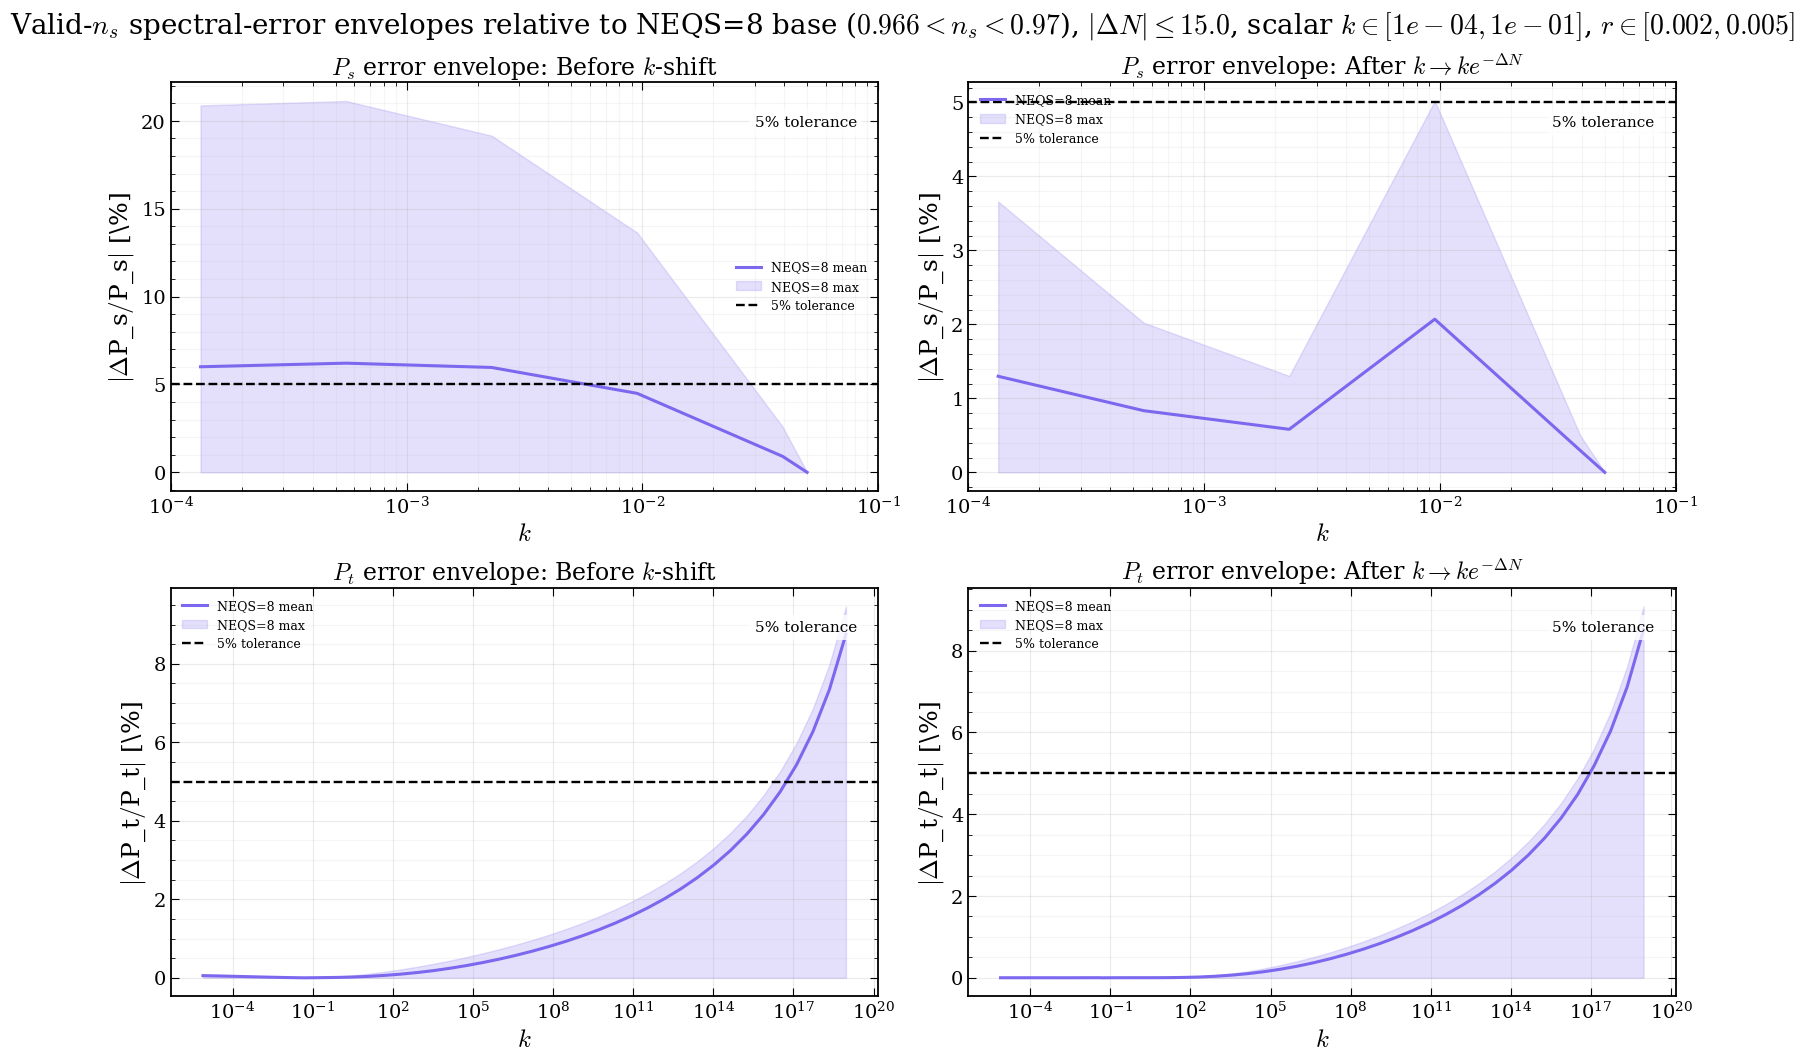


=== Cut summary ===
NEQS=8: kept=27, skipped_ns=34, skipped_r=11, skipped_deltaN=0, skipped_other=3

=== Envelope summary ===
 NEQS       case  n_models  median_mean_abs_pct  max_envelope_pct  k_min_scalar  k_max_scalar  max_abs_deltaN_cut  r_min  r_max
    8 Ps_unshift        27             5.230311         21.131531        0.0001           0.1                15.0  0.002  0.005
    8   Ps_shift        27             0.707039          5.017944        0.0001           0.1                15.0  0.002  0.005
    8 Pt_unshift        27             0.574867          9.458085           NaN           NaN                15.0  0.002  0.005
    8   Pt_shift        27             0.369767          9.079473           NaN           NaN                15.0  0.002  0.005

=== Model-level summary ===
 NEQS param_name         value        r       ns   alpha_s  original_N_end  deltaN_from_ref_base  abs_deltaN_from_ref_base  k_min_scalar  k_max_scalar  max_abs_deltaN_cut  max_Ps_unshift_pct  max_Ps_shift

In [63]:
lam_values_by_neqs = {
    8: lam5_values,
}

model_df, envelope_df = plot_valid_ns_before_after_kshift_envelopes_rminmax(
    base_path_root=base_path_root,
    lam_values_by_neqs=lam_values_by_neqs,
    ref_NEQS=8,
    ref_param="lam5",
    ref_value=-8.92461e-9,
    ns_min=0.966,
    ns_max=0.97,
    r_min=2e-3,
    r_max=5e-3,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    max_abs_deltaN=15.0,
    skip_zero=True,
    save_name="valid_ns_r_before_after_kshift.png",
)

In [64]:
bad = model_df.sort_values("max_Pt_shift_pct", ascending=False).head(5)
print(bad[[
    "value", "r", "ns", "alpha_s",
    "deltaN_from_ref_base",
    "max_Pt_shift_pct",
    "mean_Pt_shift_pct",
]])

       value         r        ns   alpha_s  deltaN_from_ref_base  \
11 -0.000029  0.003559  0.969653  0.009249             -8.388147   
7  -0.000032  0.003559  0.968167  0.007127             -8.295805   
2  -0.000038  0.003313  0.968455 -0.006939             -5.956023   
17 -0.000014  0.003307  0.969173 -0.008261             -5.903815   
22 -0.000011  0.003547  0.967231  0.006213             -8.150400   

    max_Pt_shift_pct  mean_Pt_shift_pct  
11          9.079473           1.885830  
7           9.041641           1.863183  
2           9.021148           1.803632  
17          9.020362           1.805619  
22          9.016122           1.850534  


Now, with the proper k range for tensors for our interest:

In [82]:
def plot_valid_ns_before_after_kshift_envelopes_rminmax_tensorK(
    base_path_root,
    lam_values_by_neqs,
    ref_NEQS=8,
    ref_param="lam5",
    ref_value=6.87065e-8,
    ns_min=0.963,
    ns_max=0.970,
    r_min=None,
    r_max=None,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    k_min_tensor=None,
    k_max_tensor=None,
    max_abs_deltaN=None,
    tolerance=5.0,
    skip_zero=True,
    zero_tol=1e-30,
    save_name=None,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 18,
        "axes.titlesize": 17,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 11,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    colors_by_neqs = {
        7: "plum",
        8: "mediumslateblue",
        9: "royalblue",
    }

    def folder_for(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )

    def load_specs(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def load_observables(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)
        arr = np.loadtxt(os.path.join(folder, f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]

    def get_original_N_end(NEQS, param_name, value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)
        matches = summary_df.loc[np.isclose(summary_df[param_name], value)]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for NEQS={NEQS}, "
                f"{param_name}={value:.10e}"
            )

        return float(matches.iloc[0]["original_N_end"])

    def normalize_at_k(k, P, k_ref):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside range [{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(f"Reference spectrum too small at k={k_ref}")

        return k, P / P_ref

    def frac_on_ref_grid(
        k_ref_grid,
        P_ref_norm,
        k_cmp,
        P_cmp_norm,
        kmin=None,
        kmax=None,
    ):
        k_ref_grid, P_ref_norm = prepare_increasing(k_ref_grid, P_ref_norm)
        k_cmp, P_cmp_norm = prepare_increasing(k_cmp, P_cmp_norm)

        xmin = max(k_ref_grid.min(), k_cmp.min())
        xmax = min(k_ref_grid.max(), k_cmp.max())

        if kmin is not None:
            xmin = max(xmin, kmin)

        if kmax is not None:
            xmax = min(xmax, kmax)

        if xmin >= xmax:
            return np.array([]), np.array([])

        mask = (k_ref_grid >= xmin) & (k_ref_grid <= xmax)
        k_use = k_ref_grid[mask]

        if len(k_use) == 0:
            return np.array([]), np.array([])

        P_ref_use = P_ref_norm[mask]
        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp_norm)

        frac = (P_cmp_interp - P_ref_use) / P_ref_use

        return k_use, frac

    def collect_envelope(frac_curves, k_ref_grid):
        if len(frac_curves) == 0:
            return None, None, None

        k_env = k_ref_grid.copy()
        frac_stack = []

        for k_curve, frac_curve in frac_curves:
            if len(k_curve) < 2:
                continue

            interp = np.interp(
                k_env,
                k_curve,
                frac_curve,
                left=np.nan,
                right=np.nan,
            )

            if np.all(~np.isfinite(interp)):
                continue

            frac_stack.append(interp)

        if len(frac_stack) == 0:
            return None, None, None

        frac_stack = np.array(frac_stack)

        valid_cols = np.any(np.isfinite(frac_stack), axis=0)
        frac_stack = frac_stack[:, valid_cols]
        k_env = k_env[valid_cols]

        abs_stack = np.abs(frac_stack)

        mean_abs = 100.0 * np.nanmean(abs_stack, axis=0)
        max_abs = 100.0 * np.nanmax(abs_stack, axis=0)

        return k_env, mean_abs, max_abs

    # Reference spectra
    ref_N_end = get_original_N_end(ref_NEQS, ref_param, ref_value)

    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs(
        ref_NEQS,
        ref_param,
        ref_value,
    )

    k_s_ref, Ps_ref_norm = normalize_at_k(k_s_ref_raw, Ps_ref_raw, k_norm)
    k_t_ref, Pt_ref_norm = normalize_at_k(k_t_ref_raw, Pt_ref_raw, k_norm)

    curves = {
        NEQS: {
            "Ps_unshift": [],
            "Ps_shift": [],
            "Pt_unshift": [],
            "Pt_shift": [],
            "rows": [],
            "skipped_deltaN": 0,
            "skipped_ns": 0,
            "skipped_r": 0,
            "skipped_other": 0,
        }
        for NEQS in lam_values_by_neqs.keys()
    }

    for NEQS, lam_values in lam_values_by_neqs.items():
        param_name, _ = SCAN_INFO[NEQS]

        for item in lam_values:
            value = item[0] if isinstance(item, tuple) else item
            value = float(value)

            if skip_zero and np.isclose(value, 0.0, atol=zero_tol):
                continue

            try:
                r, ns, alpha_s = load_observables(NEQS, param_name, value)

                if not (ns_min <= ns <= ns_max):
                    curves[NEQS]["skipped_ns"] += 1
                    continue

                if r_min is not None and r < r_min:
                    curves[NEQS]["skipped_r"] += 1
                    continue

                if r_max is not None and r > r_max:
                    curves[NEQS]["skipped_r"] += 1
                    continue

                model_N_end = get_original_N_end(NEQS, param_name, value)
                deltaN = model_N_end - ref_N_end
                abs_deltaN = np.abs(deltaN)

                if max_abs_deltaN is not None and abs_deltaN > max_abs_deltaN:
                    curves[NEQS]["skipped_deltaN"] += 1
                    continue

                k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(
                    NEQS,
                    param_name,
                    value,
                )

                # Unshifted comparison
                k_s_un, Ps_un = normalize_at_k(k_s_raw, Ps_raw, k_norm)
                k_t_un, Pt_un = normalize_at_k(k_t_raw, Pt_raw, k_norm)

                k_ps_un, frac_ps_un = frac_on_ref_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s_un,
                    Ps_un,
                    kmin=k_min_scalar,
                    kmax=k_max_scalar,
                )

                k_pt_un, frac_pt_un = frac_on_ref_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t_un,
                    Pt_un,
                    kmin=k_min_tensor,
                    kmax=k_max_tensor,
                )

                # Shifted comparison
                k_s_shifted = k_s_raw * np.exp(-deltaN)
                k_t_shifted = k_t_raw * np.exp(-deltaN)

                k_s_sh, Ps_sh = normalize_at_k(k_s_shifted, Ps_raw, k_norm)
                k_t_sh, Pt_sh = normalize_at_k(k_t_shifted, Pt_raw, k_norm)

                k_ps_sh, frac_ps_sh = frac_on_ref_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s_sh,
                    Ps_sh,
                    kmin=k_min_scalar,
                    kmax=k_max_scalar,
                )

                k_pt_sh, frac_pt_sh = frac_on_ref_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t_sh,
                    Pt_sh,
                    kmin=k_min_tensor,
                    kmax=k_max_tensor,
                )

                if (
                    len(frac_ps_un) == 0
                    or len(frac_ps_sh) == 0
                    or len(frac_pt_un) == 0
                    or len(frac_pt_sh) == 0
                ):
                    curves[NEQS]["skipped_other"] += 1
                    continue

                curves[NEQS]["Ps_unshift"].append((k_ps_un, frac_ps_un))
                curves[NEQS]["Ps_shift"].append((k_ps_sh, frac_ps_sh))
                curves[NEQS]["Pt_unshift"].append((k_pt_un, frac_pt_un))
                curves[NEQS]["Pt_shift"].append((k_pt_sh, frac_pt_sh))

                idx_ps_sh = np.nanargmax(np.abs(frac_ps_sh))
                idx_pt_sh = np.nanargmax(np.abs(frac_pt_sh))

                curves[NEQS]["rows"].append({
                    "NEQS": NEQS,
                    "param_name": param_name,
                    "value": value,
                    "r": r,
                    "ns": ns,
                    "alpha_s": alpha_s,
                    "original_N_end": model_N_end,
                    "deltaN_from_ref_base": deltaN,
                    "abs_deltaN_from_ref_base": abs_deltaN,

                    "k_min_scalar": k_min_scalar,
                    "k_max_scalar": k_max_scalar,
                    "k_min_tensor": k_min_tensor,
                    "k_max_tensor": k_max_tensor,

                    "max_abs_deltaN_cut": max_abs_deltaN,

                    "max_Ps_unshift_pct": 100.0 * np.nanmax(np.abs(frac_ps_un)),
                    "max_Ps_shift_pct": 100.0 * np.nanmax(np.abs(frac_ps_sh)),
                    "max_Pt_unshift_pct": 100.0 * np.nanmax(np.abs(frac_pt_un)),
                    "max_Pt_shift_pct": 100.0 * np.nanmax(np.abs(frac_pt_sh)),

                    "mean_Ps_unshift_pct": 100.0 * np.nanmean(np.abs(frac_ps_un)),
                    "mean_Ps_shift_pct": 100.0 * np.nanmean(np.abs(frac_ps_sh)),
                    "mean_Pt_unshift_pct": 100.0 * np.nanmean(np.abs(frac_pt_un)),
                    "mean_Pt_shift_pct": 100.0 * np.nanmean(np.abs(frac_pt_sh)),

                    "k_max_Ps_shift": k_ps_sh[idx_ps_sh],
                    "k_max_Pt_shift": k_pt_sh[idx_pt_sh],
                    "signed_frac_Ps_shift_at_max": 100.0 * frac_ps_sh[idx_ps_sh],
                    "signed_frac_Pt_shift_at_max": 100.0 * frac_pt_sh[idx_pt_sh],
                })

            except FileNotFoundError:
                print(f"Missing files for NEQS={NEQS}, {param_name}={value:.5e}")
                curves[NEQS]["skipped_other"] += 1

            except ValueError as e:
                print(f"Skipping NEQS={NEQS}, {param_name}={value:.5e}: {e}")
                curves[NEQS]["skipped_other"] += 1

    # Plot
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 10.5),
        constrained_layout=True,
    )

    ax_ps_un, ax_ps_sh = axes[0]
    ax_pt_un, ax_pt_sh = axes[1]

    plot_specs = [
        (
            "Ps_unshift",
            ax_ps_un,
            k_s_ref,
            k_min_scalar,
            k_max_scalar,
            r"$P_s$",
            "Before $k$-shift",
        ),
        (
            "Ps_shift",
            ax_ps_sh,
            k_s_ref,
            k_min_scalar,
            k_max_scalar,
            r"$P_s$",
            r"After $k \to k e^{-\Delta N}$",
        ),
        (
            "Pt_unshift",
            ax_pt_un,
            k_t_ref,
            k_min_tensor,
            k_max_tensor,
            r"$P_t$",
            "Before $k$-shift",
        ),
        (
            "Pt_shift",
            ax_pt_sh,
            k_t_ref,
            k_min_tensor,
            k_max_tensor,
            r"$P_t$",
            r"After $k \to k e^{-\Delta N}$",
        ),
    ]

    envelope_rows = []

    for key, ax, k_ref_grid, kmin, kmax, quantity_label, title_suffix in plot_specs:
        for NEQS in lam_values_by_neqs.keys():
            color = colors_by_neqs.get(NEQS, None)

            k_env, mean_abs, max_abs = collect_envelope(
                curves[NEQS][key],
                k_ref_grid,
            )

            if k_env is None:
                continue

            mask = np.ones_like(k_env, dtype=bool)

            if kmin is not None:
                mask &= k_env >= kmin

            if kmax is not None:
                mask &= k_env <= kmax

            k_env = k_env[mask]
            mean_abs = mean_abs[mask]
            max_abs = max_abs[mask]

            if len(k_env) == 0:
                continue

            ax.plot(
                k_env,
                mean_abs,
                color=color,
                lw=2.2,
                label=rf"NEQS={NEQS} mean",
            )

            ax.fill_between(
                k_env,
                0.0,
                max_abs,
                color=color,
                alpha=0.20,
                label=rf"NEQS={NEQS} max",
            )

            envelope_rows.append({
                "NEQS": NEQS,
                "case": key,
                "n_models": len(curves[NEQS][key]),
                "median_mean_abs_pct": np.nanmedian(mean_abs),
                "max_envelope_pct": np.nanmax(max_abs),
                "k_min_scalar": k_min_scalar if "Ps" in key else np.nan,
                "k_max_scalar": k_max_scalar if "Ps" in key else np.nan,
                "k_min_tensor": k_min_tensor if "Pt" in key else np.nan,
                "k_max_tensor": k_max_tensor if "Pt" in key else np.nan,
                "max_abs_deltaN_cut": max_abs_deltaN,
                "r_min": r_min,
                "r_max": r_max,
            })

        ax.axhline(
            tolerance,
            color="black",
            lw=1.7,
            ls="--",
            label=rf"{tolerance:.0f}% tolerance",
        )

        # Mark approximate N range on tensor panels only
        if "Pt" in key:
            k_N60 = 0.05
            k_N20 = 1e15

            ax.axvline(
                k_N60,
                color="darkgreen",
                ls="--",
                lw=2.0,
                alpha=0.9,
                label=r"$N\sim60$",
            )

            ax.axvline(
                k_N20,
                color="firebrick",
                ls="--",
                lw=2.0,
                alpha=0.9,
                label=r"$N\sim20$",
            )

            y_text = ax.get_ylim()[1] * 0.75

            ax.text(
                k_N60,
                y_text,
                r"$N\sim60$",
                rotation=90,
                color="darkgreen",
                ha="right",
                va="top",
                fontsize=10,
            )

            ax.text(
                k_N20,
                y_text,
                r"$N\sim20$",
                rotation=90,
                color="firebrick",
                ha="right",
                va="top",
                fontsize=10,
            )

        ax.set_xscale("log")

        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()

        ax.set_title(rf"{quantity_label} error envelope: {title_suffix}")
        ax.set_xlabel(r"$k$")
        ax.set_ylabel(rf"$|\Delta {quantity_label}/{quantity_label}|$ [\%]")

        if kmin is not None or kmax is not None:
            xmin = kmin if kmin is not None else k_ref_grid.min()
            xmax = kmax if kmax is not None else k_ref_grid.max()
            ax.set_xlim(xmin, xmax)

        ax.legend(
            fontsize=9,
            frameon=False,
            loc="best",
        )

    cut_text = ""

    if max_abs_deltaN is not None:
        cut_text += rf", $|\Delta N| \leq {max_abs_deltaN}$"

    if k_min_scalar is not None or k_max_scalar is not None:
        kmin_text = k_min_scalar if k_min_scalar is not None else k_s_ref.min()
        kmax_text = k_max_scalar if k_max_scalar is not None else k_s_ref.max()
        cut_text += rf", scalar $k\in[{kmin_text:.0e},{kmax_text:.0e}]$"

    if k_min_tensor is not None or k_max_tensor is not None:
        kmin_text = k_min_tensor if k_min_tensor is not None else k_t_ref.min()
        kmax_text = k_max_tensor if k_max_tensor is not None else k_t_ref.max()
        cut_text += rf", tensor $k\in[{kmin_text:.0e},{kmax_text:.0e}]$"

    if r_min is not None or r_max is not None:
        rmin_text = r_min if r_min is not None else 0.0
        rmax_text = r_max if r_max is not None else np.inf
        cut_text += rf", $r\in[{rmin_text:.2g},{rmax_text:.2g}]$"

    fig.suptitle(
        rf"Valid-$n_s$ spectral-error envelopes relative to NEQS={ref_NEQS} base "
        rf"(${ns_min}<n_s<{ns_max}$){cut_text}",
        fontsize=20,
    )

    if save_name is None:
        save_name = (
            f"valid_ns_r_tensorK_error_envelopes_before_after_shift_"
            f"ref_neqs{ref_NEQS}.png"
        )

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    model_rows = []
    for NEQS in lam_values_by_neqs.keys():
        model_rows.extend(curves[NEQS]["rows"])

    model_df = pd.DataFrame(model_rows)
    envelope_df = pd.DataFrame(envelope_rows)

    print("\n=== Cut summary ===")
    for NEQS in lam_values_by_neqs.keys():
        print(
            f"NEQS={NEQS}: kept={len(curves[NEQS]['rows'])}, "
            f"skipped_ns={curves[NEQS]['skipped_ns']}, "
            f"skipped_r={curves[NEQS]['skipped_r']}, "
            f"skipped_deltaN={curves[NEQS]['skipped_deltaN']}, "
            f"skipped_other={curves[NEQS]['skipped_other']}"
        )

    print("\n=== Envelope summary ===")
    if not envelope_df.empty:
        print(envelope_df.to_string(index=False))

    print("\n=== Model-level summary ===")
    if not model_df.empty:
        print(model_df.to_string(index=False))

    return model_df, envelope_df

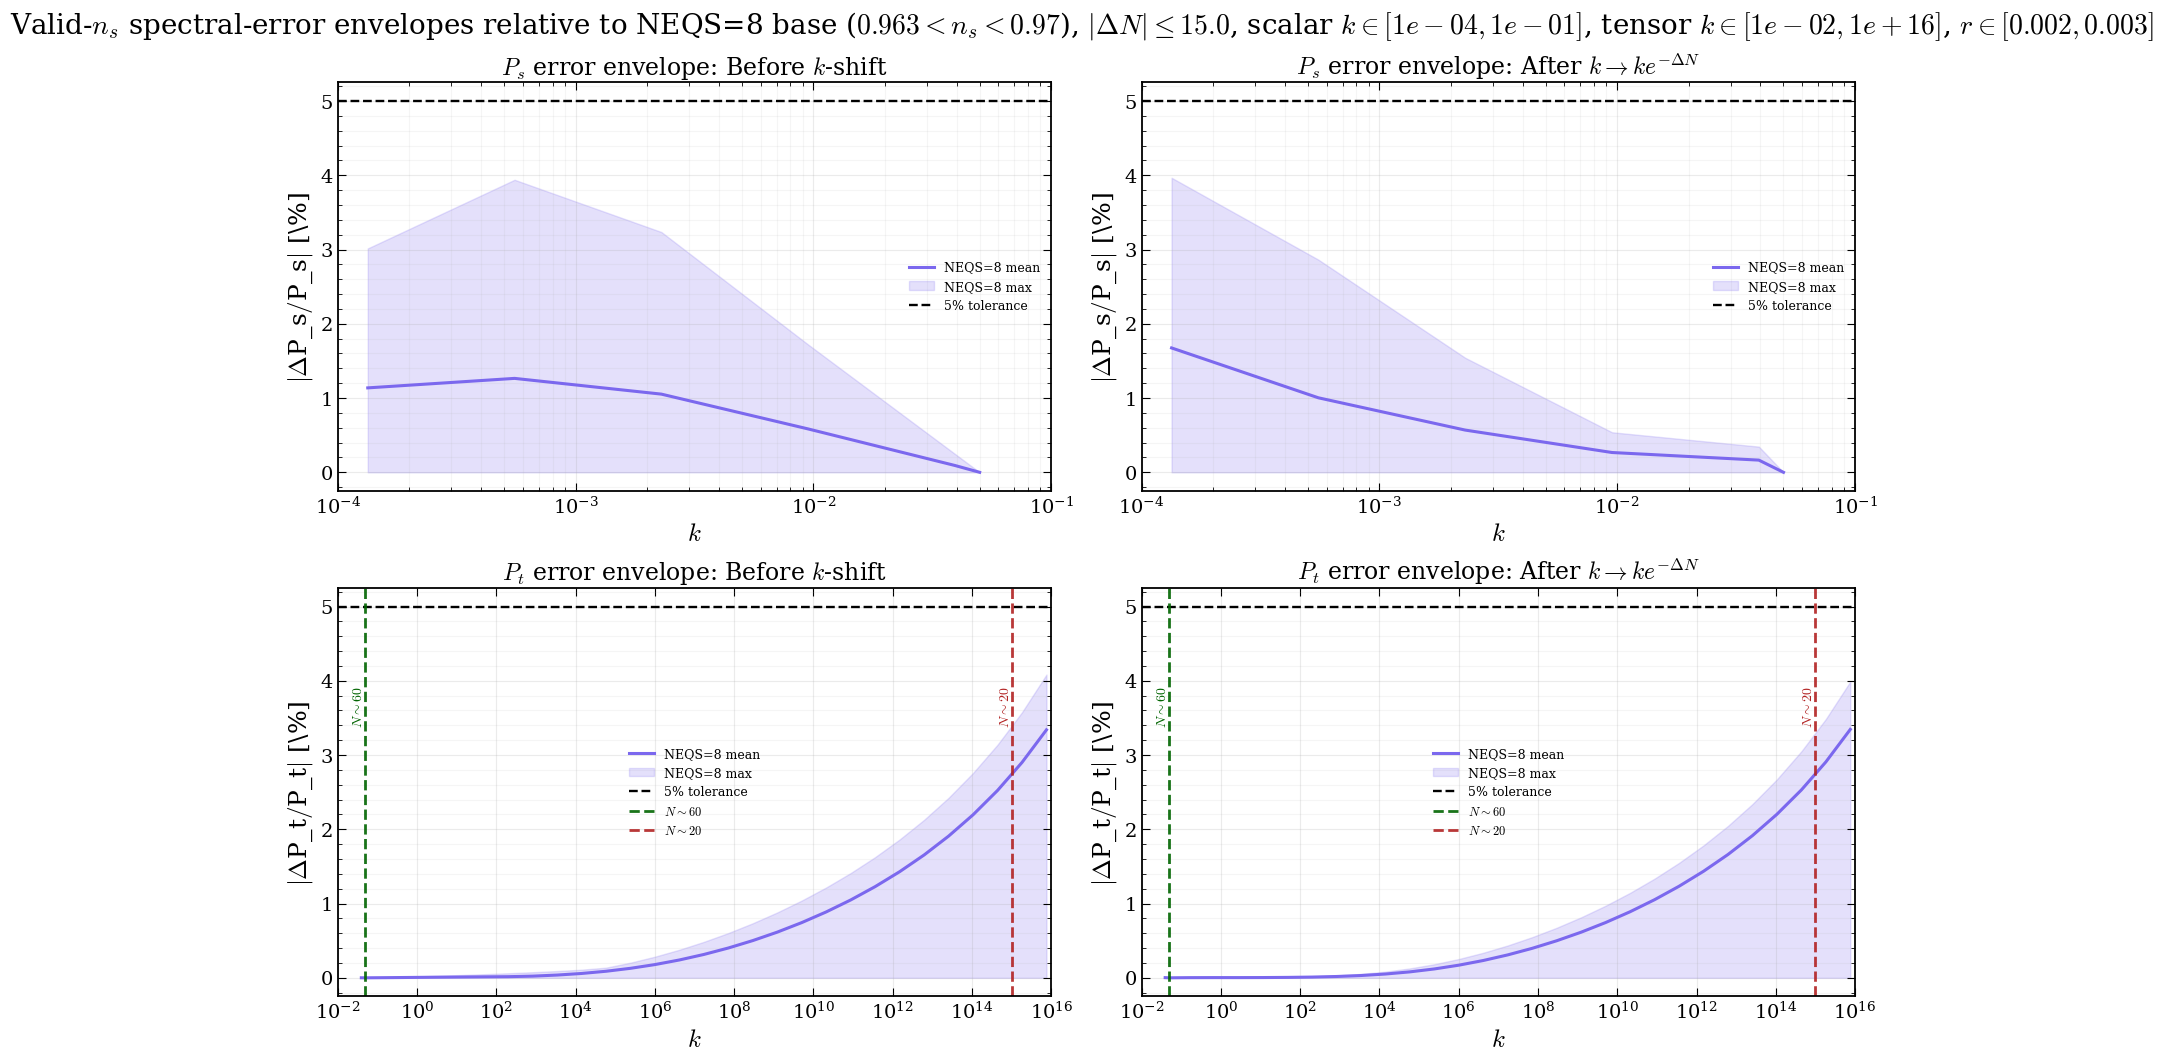


=== Cut summary ===
NEQS=8: kept=8, skipped_ns=0, skipped_r=67, skipped_deltaN=0, skipped_other=0

=== Envelope summary ===
 NEQS       case  n_models  median_mean_abs_pct  max_envelope_pct  k_min_scalar  k_max_scalar  k_min_tensor  k_max_tensor  max_abs_deltaN_cut  r_min  r_max
    8 Ps_unshift         8             0.818383          3.939218        0.0001           0.1           NaN           NaN                15.0  0.002  0.003
    8   Ps_shift         8             0.417633          3.966358        0.0001           0.1           NaN           NaN                15.0  0.002  0.003
    8 Pt_unshift         8             0.277597          4.083829           NaN           NaN          0.01  1.000000e+16                15.0  0.002  0.003
    8   Pt_shift         8             0.270922          3.989718           NaN           NaN          0.01  1.000000e+16                15.0  0.002  0.003

=== Model-level summary ===
 NEQS param_name         value        r       ns   alpha_s  origin

In [102]:
model_df, envelope_df = plot_valid_ns_before_after_kshift_envelopes_rminmax_tensorK(
    base_path_root=base_path_root,
    lam_values_by_neqs={8: lam5_values},
    ref_NEQS=8,
    ref_param="lam5",
    ref_value=-8.92461e-9,

    ns_min=0.963,
    ns_max=0.970,
    r_min=2e-3,
    r_max=3e-3, #3e-3 gets right below 5%

    k_norm=0.05,

    # scalar comparison range
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,

    # tensor comparison range: roughly CMB/PTA/LISA window
    k_min_tensor=1e-2,
    k_max_tensor=1e16,

    max_abs_deltaN=15.0,
    tolerance=5.0,
    skip_zero=True,
    save_name="valid_ns_r_tensorK_before_after_kshift_nonhiggs.png",
)

What were we seeing?

Initially, I was seeing a wide range of $N_{end}$ values and as such saw a wide spread in $\Delta$$ N$. That was not necessarily expected because we assumed that we would be basically looking at the exact same model for the $n_s$ range specified. HOWEVER, specifying $n_s$ in the way we did from 0.963-0.97 is not actually sufficient to define the model space of interest. It would seem it still gave us a healthy spread of solutions. There was a space of solutions near the reference model and two more spaces, one that was approximately 60 or so away from the reference and another that was 200 away. Since we are interested in the variation of one trajectory, and accounting for the effects of the higher order parameters for that trajectory it is imperative that we manage to properly define the model solution we want to identify. 

A better way to identify the trajectory of interest is to not only apply $n_s$ constrained but additionally apply $r$ as well. $n_s$ is defined in terms of the first three slow roll parameters and $r$ is directly proportional to $\epsilon$. The first slow roll parameter, $\epsilon$ is also how we define the end of inflation when $\epsilon=1$. Without defining $r$ we open up the space of models which correspond to more values of $\epsilon$ that are likely not on the same trajectory we are interested in, but may still provide a solution.

It was once I applied a constraint to both $n_s$+$r$ that when I examined the $\Delta$$ N$ these were all less than 11 e-folds away from the reference model. Together, these cuts isolate the background enough!! As is evident for each of these models with both cuts, each one ends inflation at slightly different times. This is almost like toggling the start of reheating to be either earlier or later than our given model. It is acting like an uncertainty parameter encoding shifts induced by higher-order slow-roll terms and, more broadly, uncertainties in the post-inflationary mapping such as reheating.
When ran like so with each of these models, we can recover a scalar and tensor spectrum error less than 5% relative to that base model after accounting for the shift due to $\Delta$$ N$. 

When looking at the plot of the scalar and tensor power spectra before and after applying the shift one may wonder why we even get such a shift to begin with. This spread in Ps/Pt likely exists because $N_end$ is an integrated quantity. Even small changes in the higher order slow-roll parameters can slightly change the trajectory of $\epsilon(N)$ and thus where inflation actually ends. So maybe two models can have similar $n_s$ values but they hit $\epsilon=1$ at different points as we saw. $n_s$ is just a local condition at/near the pivot. $N_{end}$ is the entire path to the end of inflation, to constrain that $\epsilon$ we also need that $r$. Together $n_s$ and $r$ constrain that pathway/background much much better. That $\Delta$$ N$ tells us the leftover horizontal shift due to the variation in the models, but with $n_s$ + $r$ constrained we can make sure that is representative of the model in question. 

If I did not apply the $\Delta$$ N$ shift whatsoever then I'm basically looking at models that appear to have a substantial shift in their spectra which we might interpret as being wildly different--and thus producing very different tensor spectra--but that ain't the case once you fold in their $\Delta$$ N$ for that is the dominant effect making the spectra appear quite different. The code when initialized and defined near a solution, explores the nearby parameter trajectories which are going to primarily differ when inflation ends. Accounting for the $\Delta$$ N$ shift allows you to properly probe the solution space while correcting for the dominant horizontal displacement in the spectraaaaaa.




The proposed workflow is therefore: first define a model-specific observational window in ($n_s$) and ($r$); then compute ($\Delta$$ N$) relative to a reference model it should not spread out that much tbh; then apply a modest (|$\Delta$$ N$|) cut to select models belonging to the same local solution branch if necessary but should not be; finally, apply the ($k$)-shift and quantify the residual scalar and tensor spectral errors. 

This provides a practical way to identify viable model space across CMB, PTA, and space-interferometer scales while separating genuine shape differences from uncertainties in the scale-to-e-fold mapping.

